In [ ]:

!pip install numpyro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 27.5 MB/s eta 0:00:00


In [ ]:
# check this if running on GPU
import jax

# Use 32-point precision
jax.config.update("jax_enable_x64", False)

jax.default_backend()

'gpu'

In [ ]:
jax.devices()

[CudaDevice(id=0)]

In [ ]:
# Set up file system
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [ ]:
# download the git repo
!git clone https://github.com/ConorMesser/stats_305c.git

Cloning into 'stats_305c'...
remote: Enumerating objects: 177, done.
remote: Counting objects: 100% (177/177), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 177 (delta 98), reused 103 (delta 42), pack-reused 0 (from 0)
Receiving objects: 100% (177/177), 24.68 MiB | 13.22 MiB/s, done.
Resolving deltas: 100% (98/98), done.


In [ ]:
!cd stats_305c/; git pull

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 400 bytes | 400.00 KiB/s, done.
From https://github.com/ConorMesser/stats_305c
   0221a9f..b88c2dd  main       -> origin/main
Updating 0221a9f..b88c2dd
Fast-forward
 pmf_model.py | 11 ++++++++---
 1 file changed, 8 insertions(+), 3 deletions(-)


In [ ]:
import stats_305c.pmf_model
import importlib

importlib.reload(stats_305c.pmf_model)

<module 'stats_305c.pmf_model' from '/content/stats_305c/pmf_model.py'>

In [ ]:
from stats_305c.pmf_model import Hybrid_PMF
from stats_305c.utils import compute_metrics, split_random_mask, split_holdout_peptides

In [ ]:

import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns
import arviz as az
import pymc as pm
from sklearn.preprocessing import StandardScaler
import pandas as pd
import math
import xarray as xr
import scipy.stats as stats
from scipy.stats import norm
from scipy.special import logsumexp
from pymc.sampling.jax import sample_numpyro_nuts
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib


# Load and Process Data

In [ ]:
# file_path = '/content/drive/MyDrive/STATS305c/' # Lauren
file_path = '/content/drive/MyDrive/Courses/STATS305c/' # Conor

mic_file = pathlib.Path(os.path.join(file_path, 'data', 'MIC_data_cleaned.csv'))
cp_file = pathlib.Path(os.path.join(file_path, 'data', 'all_chem_phys_features.txt'))
embed_file = pathlib.Path(os.path.join(file_path, 'embeddings', 'all_embeddings.tsv'))

full_mic_data = pd.read_csv(mic_file)
all_chem_phys = pd.read_csv(cp_file, sep='\t', index_col=0)
all_chem_phys.index.name = 'Peptide ID'
all_embeddings = pd.read_csv(embed_file, sep='\t', index_col=0)
all_embeddings.index.name = 'Peptide ID'

# read in the taxonomy data
taxonomy_species = pd.read_csv(os.path.join(file_path, 'data', 'species_taxonomy.tsv'), sep='\t')
taxonomy_species['Target Species'] = taxonomy_species['strain']

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler (calculates mean and std) and transform the data
pc_features = all_chem_phys.iloc[:, 1:13]
pc_normalized_array = scaler.fit_transform(pc_features)

# It returns a numpy array, so convert it back to a DataFrame to keep your column names
pc_normalized = all_chem_phys.copy()
pc_normalized.iloc[:, 1:13] = pc_normalized_array

/tmp/ipykernel_3811/1505902065.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.14303094 -2.58278073 -0.71110601 ... -0.56713103 -0.27918107
 -0.13520609]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pc_normalized.iloc[:, 1:13] = pc_normalized_array
/tmp/ipykernel_3811/1505902065.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.00513085 -0.74668439 -0.02494176 ... -0.20537742  0.21563911
  0.12542129]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pc_normalized.iloc[:, 1:13] = pc_normalized_array


## Get PCs from ESM features


In [ ]:

# Assuming your esm_df has the peptide IDs as the index
# and the 1280 features as the columns.
esm_features = all_embeddings.values

# 1. Standardize the features (Crucial before PCA)
scaler = StandardScaler()
esm_scaled = scaler.fit_transform(esm_features)

# 2. Fit the full PCA to analyze the variance
pca_full = PCA()
pca_full.fit(esm_scaled)

# 3. Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 4. Find the exact number of components for your thresholds
k_50 = np.argmax(cumulative_variance >= 0.50) + 1
k_70 = np.argmax(cumulative_variance >= 0.70) + 1
k_90 = np.argmax(cumulative_variance >= 0.90) + 1
k_95 = np.argmax(cumulative_variance >= 0.95) + 1
k_99 = np.argmax(cumulative_variance >= 0.99) + 1

chosen_k = k_90
print(chosen_k)

pca_final = PCA(n_components=chosen_k)
esm_pca_transformed = pca_final.fit_transform(esm_scaled)

# 2. Convert back to a DataFrame to keep your peptide index intact
esm_pca_df = pd.DataFrame(
    esm_pca_transformed,
    index=all_embeddings.index,
    columns=[f"PC_{i+1}" for i in range(chosen_k)]
)

62


## Prepare data inputs
Filter species, scale by global mean, etc.

In [ ]:
# ESM and Feature inputs
phys_chem_norm = pc_normalized.iloc[:, 1:-3].astype('float32').copy()
esm_pca_input = esm_pca_df.astype('float32').copy()
esm_input = pd.DataFrame(esm_scaled, index=esm_pca_df.index).astype('float32')

# drop nas
na_peptides = phys_chem_norm[phys_chem_norm.isna().any(axis=1)].index
phys_chem_norm.drop(index=na_peptides, inplace=True)
esm_input.drop(index=na_peptides, inplace=True)

peptides_w_data = list(set(full_mic_data['Peptide ID']) & set(all_chem_phys.index))
has_data = full_mic_data[full_mic_data['Peptide ID'].isin(peptides_w_data) &
                         ~full_mic_data['Peptide ID'].isin(na_peptides)]

has_data['mic_untransformed'] = np.log2(has_data['Activity_uM'].astype('float32'))

# Generate:
# - Test data (only a few species)
# - Selective species (~10) in 2 genus for testing hierarchical model
# - Abudnant species (>200 counts)
# - Most species (>10 counts)

def get_mic_df(original_df, species, name=''):
    test_mic = original_df[original_df['Target Species'].isin(species)].dropna(subset=['Peptide ID', 'Target Species', 'Activity_uM', 'Activity_low_uM'])
    mic_scaler = StandardScaler(with_mean=True, with_std=False)
    test_mic['mic'] = mic_scaler.fit_transform(test_mic[['mic_untransformed']].values)
    ### Changed this to save the transformed value as the mic - but should I just subtract the global mean or is the sigma transformation necessary too???

    print('\nFor model:', name)
    print('Total number of observations:', test_mic.shape[0])
    print('Num peptides:', test_mic['Peptide ID'].nunique())
    print('Num strains:', test_mic['Target Species'].nunique())
    return test_mic, mic_scaler

# - Test data (only a few species)
few_species = has_data.groupby('Target Species').size().sort_values(ascending=False).iloc[:3].index
test_few_df, test_few_scaler = get_mic_df(has_data, few_species, name='test_few')

# - Selective species in 2 genus for testing hierarchical model
tmp = has_data.groupby('Target Species').size().to_frame().join(taxonomy_species.set_index('Target Species'), how='left')
tmp = tmp[tmp['genus'].isin(['Candida','Streptococcus'])]
selective_strains = tmp[(tmp[0] > 10) & (tmp[0] < 200)]['strain'].unique()
selective_df, selective_scaler = get_mic_df(has_data, selective_strains, name='test_selective')

# - Abudnant species (>200 counts)
species_counts = has_data.groupby('Target Species').size()
top_species = species_counts[species_counts > 200].index
abundant_df, abundant_scaler = get_mic_df(has_data, top_species, name='abundant')

# - Most species (>10 counts) - lower for hierarchical model
most_species = species_counts[species_counts > 10].index
most_species_df, most_species_scaler = get_mic_df(has_data, most_species, name='most_species')


/tmp/ipykernel_3811/2748965944.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  has_data['mic_untransformed'] = np.log2(has_data['Activity_uM'].astype('float32'))



For model: test_few
Total number of observations: 13291
Num peptides: 6128
Num strains: 3

For model: test_selective
Total number of observations: 3426
Num peptides: 2244
Num strains: 91

For model: abundant
Total number of observations: 42668
Num peptides: 10473
Num strains: 56

For model: most_species
Total number of observations: 79805
Num peptides: 12617
Num strains: 1093


In [ ]:

# train-test split not really needed given LOOCV, but we can use it for final model evaluation
train_df, hold_peptides_test = split_holdout_peptides(most_species_df, holdout_frac=0.05, random_state=42)
# train_df, random_test = split_random_mask(train_df, holdout_frac=0.10, random_state=42)

[peptide holdout]  train peptides=11987  test peptides=630  (3901 obs)


# Input Data Figures and Calculations




## Variation in Repeats

In [ ]:
# Variation in repeated measures - can compare this to the training error
subset = ['Peptide ID', 'Target Species']
repeated_measures = most_species_df[most_species_df.duplicated(subset=subset, keep=False)]

In [ ]:
repeated_measures.groupby(subset)['mic'].std().describe()

,mic
count,4468.000000
mean,1.216040
std,0.977067
min,0.000000
25%,0.658199
50%,1.000000
75%,1.704413
max,8.115496


In [ ]:
means = repeated_measures.groupby(subset)['mic'].mean()
np.sqrt((repeated_measures.apply(lambda x: x['mic'] - means.loc[(x['Peptide ID'], x['Target Species'])], axis=1) ** 2).mean())

np.float32(1.2162502)

### Data Sparsity

In [ ]:
most_species_df.shape

(79805, 26)

In [ ]:
most_species_df['Peptide ID'].nunique()

12617

In [ ]:
most_species_df['Target Species'].nunique()

1093

In [ ]:
has_data_tax = taxonomy_species[taxonomy_species['Target Species'].isin(most_species_df['Target Species'])].drop_duplicates()
has_data_tax['genus'].nunique()

101

In [ ]:
has_data_tax['species'].nunique()

207

In [ ]:
most_species_df.groupby(['Peptide ID']).size()

,0
Peptide ID,
8,8
11,40
12,6
14,16
15,7
...,...
22722,2
22723,2
22724,2


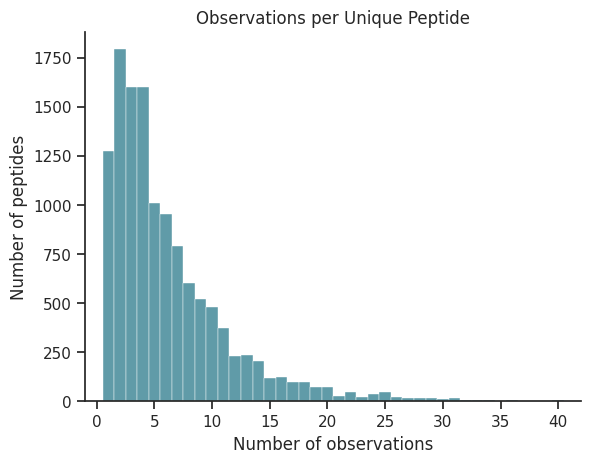

In [ ]:
peptide_counts = most_species_df.groupby(['Peptide ID']).size()
ax = sns.histplot(peptide_counts.values, discrete=True, color='#2b7a8bff', edgecolor='white')

plt.xlim((-1, 42))
sns.despine()
ax.set_title("Observations per Unique Peptide")
ax.set_xlabel("Number of observations")
ax.set_ylabel("Number of peptides")

plt.savefig(os.path.join(file_path, 'figures', 'unique_peptide_counts.png'), bbox_inches='tight')


In [ ]:
le_5_peptides = (peptide_counts <= 5).sum()
print(le_5_peptides)
print(le_5_peptides / peptide_counts.shape[0])

7279
0.5769200285329318


<Axes: ylabel='Count'>

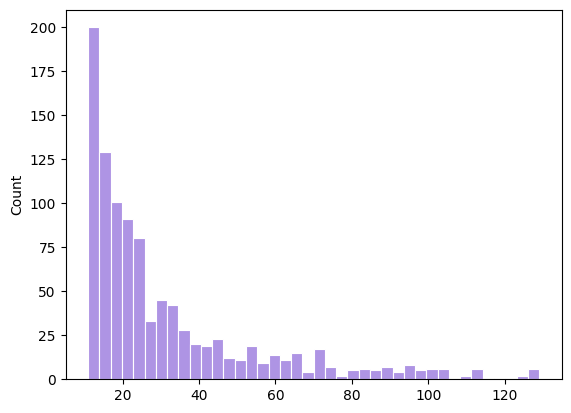

In [ ]:
strain_counts = most_species_df.groupby(['Target Species']).size()
sns.histplot(strain_counts[strain_counts < 130].values, bins=40, color='mediumpurple', edgecolor='white')

In [ ]:
(strain_counts < 25).sum()

np.int64(587)

In [ ]:

strain_counts.shape

(1093,)

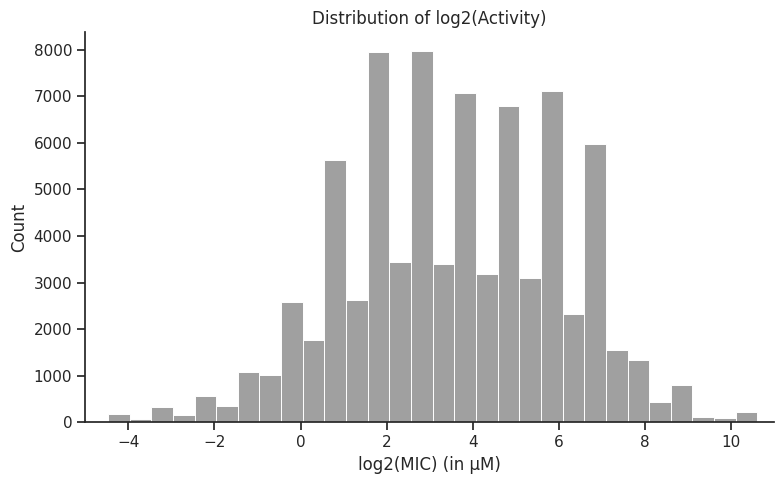

In [ ]:
viz = most_species_df.copy()
sns.set_theme(style="ticks") # whitegrid

# 1. Target variable: log2(Activity_uM) distribution
plt.figure(figsize=(8, 5))
sns.histplot(viz["mic_untransformed"], binwidth=0.5, color="gray", edgecolor="white")
plt.title("Distribution of log2(Activity)")
plt.xlabel("log2(MIC) (in µM)")
plt.ylabel("Count")
plt.xlim((-5, 11))
plt.tight_layout()
sns.despine()

plt.savefig(os.path.join(file_path, 'figures', 'MIC_activities_plot.png'), bbox_inches='tight')
plt.show()

### More data

In [ ]:
most_species_df['censored_high'].sum()

np.int64(16089)

In [ ]:
2 ** (most_species_df[most_species_df['censored_high']]['mic_untransformed'].mean() - most_species_df[~most_species_df['censored_high']]['mic_untransformed'].mean())

np.float32(9.675903)

In [ ]:
most_species_df['Peptide ID'].value_counts().describe()

,count
count,12617.000000
mean,6.325196
std,5.860462
min,1.000000
25%,3.000000
50%,5.000000
75%,8.000000
max,111.000000


In [ ]:
(most_species_df['Peptide ID'].value_counts() == 1).sum()

np.int64(1275)

In [ ]:
most_species_df.groupby(['Peptide ID', 'Target Species']).count()['mic'].reset_index()['Target Species'].value_counts().describe()

,count
count,1093.000000
mean,66.439158
std,231.432617
min,2.000000
25%,14.000000
50%,22.000000
75%,45.000000
max,4749.000000


In [ ]:
tmp = most_species_df.groupby(['Peptide ID', 'Target Species']).count()['mic']
(tmp > 1).sum()

np.int64(4468)

In [ ]:
tmp[tmp > 1].sum()

np.int64(11655)

In [ ]:
11655 - 4468

7187

# Run Models

## Full Model

In [ ]:
hpmf_model_wESMmixed_Hie = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), taxonomy_species,
                                 dim=6, horseshoe_u=False, horseshoe_intercept=True, non_centered=True,
                                 hierarchical=True, anchor_pc=True,
                                 esm_intercept=esm_input.copy(), esm_interaction=esm_pca_input.copy(),
                                 sigma_obs_sigma=3, beta_sigma=2,
                                 esm_active_num=15, slab_scale = 4.0)

idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_wESMmixed_Hie.5_25.gt_10_species.nc"))
hpmf_model_wESMmixed_Hie.idata = idata

/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(


In [ ]:
train_ESMmixed_Hie_out, test_ESMmixed_Hie_out, ESMmixed_Hie_performance = hpmf_model_wESMmixed_Hie.full_evaluation(hold_peptides_test)
ESMmixed_Hie_performance

Output()

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Output()

Output()

Output()

{'rmse_train': np.float64(1.6022188938695918),
 'rmse_test': np.float64(2.301914128131597),
 'elpd_train': np.float64(-148907.07595923071),
 'elpd_test': np.float64(-8990.605568466639)}

In [ ]:
train_ESMmixed_Hie_out = pd.read_csv(os.path.join(file_path, "saved_models", "hpmf_model_wESMmixed_Hie.5_25.gt_10_species.train_out.txt"), sep='\t')
test_ESMmixed_Hie_out= pd.read_csv(os.path.join(file_path, "saved_models", "hpmf_model_wESMmixed_Hie.5_25.gt_10_species.test_out.txt"), sep='\t')

In [ ]:
mean_train_err = (train_ESMmixed_Hie_out['error'] ** 2).mean()
std_train_err = (train_ESMmixed_Hie_out['error'] ** 2).std()

In [ ]:
(train_ESMmixed_Hie_out['error'] ** 2 > (mean_train_err + 3*std_train_err)).sum()

np.int64(1247)

In [ ]:
train_ESMmixed_Hie_out.shape

(75904, 31)

In [ ]:
1247 / 75904

0.016428646711635752

In [ ]:
np.exp(-4)

np.float64(0.01831563888873418)

In [ ]:
(train_ESMmixed_Hie_out['elpd'] < -4).sum()

np.int64(2153)

(-7.0, 0.0)

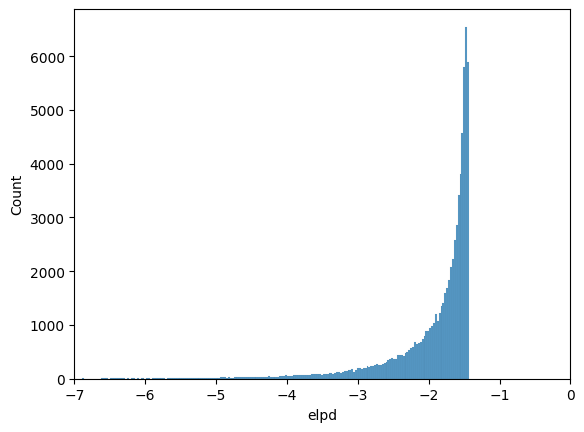

In [ ]:
sns.histplot(train_ESMmixed_Hie_out['elpd'])
plt.xlim((-7, 0))

<Axes: xlabel='elpd', ylabel='Count'>

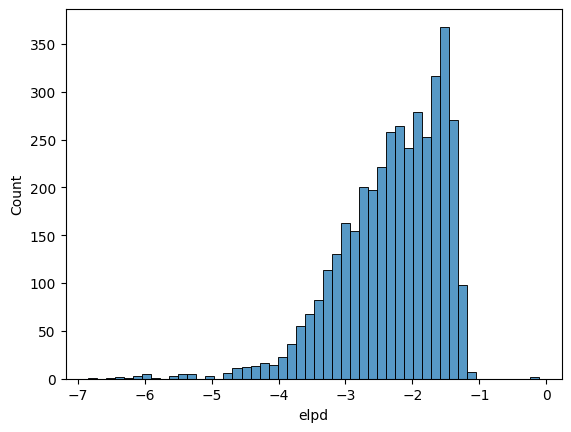

In [ ]:
sns.histplot(test_ESMmixed_Hie_out['elpd'])

In [ ]:
(test_ESMmixed_Hie_out['elpd'] < -4).sum()

np.int64(105)

In [ ]:
# Run Diagnositcs - R-hat over all parameters, ESS
# Seems small ESS for some params...

In [ ]:
hpmf_model_wESMmixed_Hie.idata.posterior

<xarray.Dataset> Size: 3GB
Dimensions:             (chain: 2, draw: 1000, B_pc_bottom_dim_0: 6,
                         B_pc_bottom_dim_1: 6, B_pc_diag_dim_0: 6,
                         B_pc_lower_dim_0: 15, peptide: 11987,
                         latent_factor: 6, genus: 350, species: 791,
                         strain: 1093, esm_intercept: 1280, obs_id: 75904,
                         var_fracs_dim_0: 3, phys_chem: 12)
Coordinates: (12/15)
  * chain               (chain) int64 16B 0 1
  * draw                (draw) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
  * B_pc_bottom_dim_0   (B_pc_bottom_dim_0) int64 48B 0 1 2 3 4 5
  * B_pc_bottom_dim_1   (B_pc_bottom_dim_1) int64 48B 0 1 2 3 4 5
  * B_pc_diag_dim_0     (B_pc_diag_dim_0) int64 48B 0 1 2 3 4 5
  * B_pc_lower_dim_0    (B_pc_lower_dim_0) int64 120B 0 1 2 3 4 ... 11 12 13 14
    ...                  ...
  * species             (species) int64 6kB 0 1 2 3 4 5 ... 786 787 788 789 790
  * strain              (strain) int64 9kB 0 1 2 3 4 ... 1089 1090 1091 1092
  * esm_intercept       (esm_intercept) int64 10kB 0 1 2 3 ... 1277 1278 1279
  * obs_id              (obs_id) int64 607kB 0 1 2 3 ... 75900 75901 75902 75903
  * var_fracs_dim_0     (var_fracs_dim_0) int64 24B 0 1 2
  * phys_chem           (phys_chem) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
Data variables: (12/33)
    B_pc_bottom         (chain, draw, B_pc_bottom_dim_0, B_pc_bottom_dim_1) float64 576kB ...
    B_pc_diag           (chain, draw, B_pc_diag_dim_0) float64 96kB ...
    B_pc_lower          (chain, draw, B_pc_lower_dim_0) float64 240kB ...
    U                   (chain, draw, peptide, latent_factor) float64 1GB ...
    V_genus             (chain, draw, genus, latent_factor) float64 34MB ...
    V_genus_raw         (chain, draw, genus, latent_factor) float64 34MB ...
    ...                  ...
    tau_esm_int         (chain, draw) float64 16kB ...
    var_fracs           (chain, draw, var_fracs_dim_0) float64 48kB ...
    w0_esm              (chain, draw, esm_intercept) float64 20MB ...
    w0_esm_raw          (chain, draw, esm_intercept) float64 20MB ...
    w0_pc               (chain, draw, phys_chem) float64 192kB ...
    w0_pc_sigma         (chain, draw) float64 16kB ...
Attributes:
    created_at:                 2026-05-24T07:35:44.126921+00:00
    arviz_version:              0.22.0
    inference_library:          numpyro
    inference_library_version:  0.21.0
    sampling_time:              2226.143823
    tuning_steps:               1500

In [ ]:
pep_features = az.summary(hpmf_model_wESMmixed_Hie.idata,
                          var_names=["w0_esm", "w0_pc", "B_esm", "B_pc_anchors", "B_pc_raw"],
                          # coords={'esm_intercept': np.random.choice(np.arange(1280), 100, replace=False),
                          #         'esm_interaction': np.random.choice(np.arange(62), 40, replace=False)}
                          )
pep_features['type'] = pep_features.index.map(lambda x: x.split('[')[0])
pep_features.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)

/tmp/ipykernel_9421/1941926489.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pep_features.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)


ess_bulk                                                     \
type        B_esm B_pc_anchors     B_pc_raw       w0_esm       w0_pc   
count  372.000000     6.000000    72.000000  1280.000000   12.000000   
mean     8.543011    12.500000    90.541667   814.982031  481.916667   
std      5.429358     4.929503   267.287730   236.268398   92.176174   
min      5.000000     6.000000     5.000000   295.000000  321.000000   
25%      6.000000     8.750000     6.000000   633.750000  431.500000   
50%      7.000000    13.000000     8.000000   791.000000  486.500000   
75%      9.000000    16.500000    15.250000   971.250000  534.000000   
max     53.000000    18.000000  1091.000000  1674.000000  669.000000   

         ess_tail                                                      \
type        B_esm B_pc_anchors     B_pc_raw       w0_esm        w0_pc   
count  372.000000     6.000000    72.000000  1280.000000    12.000000   
mean    41.741935    75.666667   199.430556  1638.991406  1033.583333   
std     55.810017    76.852239   399.128199   691.073393   161.837999   
min     11.000000    28.000000    12.000000   134.000000   739.000000   
25%     20.000000    35.500000    28.750000  1029.500000   923.000000   
50%     29.000000    50.000000    40.000000  1763.000000  1029.500000   
75%     42.000000    61.500000   118.250000  2212.000000  1146.000000   
max    604.000000   230.000000  1629.000000  3030.000000  1330.000000   

            r_hat                                                  
type        B_esm B_pc_anchors   B_pc_raw       w0_esm      w0_pc  
count  372.000000     6.000000  72.000000  1280.000000  12.000000  
mean     1.610591     1.316667   1.502917     1.003805   1.008333  
std      0.298641     0.198057   0.368038     0.005031   0.007177  
min      1.060000     1.140000   1.000000     1.000000   1.000000  
25%      1.360000     1.192500   1.195000     1.000000   1.000000  
50%      1.600000     1.235000   1.460000     1.000000   1.010000  
75%      1.830000     1.397500   1.732500     1.010000   1.010000  
max      2.480000     1.660000   2.450000     1.020000   1.020000

In [ ]:
intercepts_interactions = az.summary(hpmf_model_wESMmixed_Hie.idata,
                        var_names=["alpha_peptide", "beta_genus", "beta_species", "beta_strain",
                                   "U", "V_genus", "V_species", "V_strains"],
                        coords={'peptide': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["peptide"], 1000, replace=False),
                                'genus': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["genus"], 50, replace=False),
                                'species': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["species"], 200, replace=False),
                                'strain': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["strain"], 500, replace=False)}
                                     )
intercepts_interactions['type'] = intercepts_interactions.index.map(lambda x: x.split('[')[0])
intercepts_interactions.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)

/tmp/ipykernel_9421/3399812083.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  intercepts_interactions.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)


ess_bulk                                                      \
type             U      V_genus    V_species   V_strains alpha_peptide   
count  6000.000000   300.000000  1200.000000  3000.00000    1000.00000   
mean      6.791167   842.496667   571.301667    54.17100     969.23400   
std       3.257707   303.055173   434.729313   131.22382     187.36782   
min       5.000000     7.000000     5.000000     5.00000     436.00000   
25%       6.000000   844.500000    37.000000     9.00000     831.00000   
50%       6.000000   941.000000   795.500000    16.00000     965.00000   
75%       7.000000  1011.750000   961.250000    33.00000    1085.00000   
max     128.000000  1299.000000  1211.000000  1078.00000    1577.00000   

                                                 ess_tail               ...  \
type    beta_genus beta_species  beta_strain            U      V_genus  ...   
count    50.000000    200.00000   500.000000  6000.000000   300.000000  ...   
mean    806.620000    718.49000   864.556000    25.812000  1398.483333  ...   
std     183.483402    190.41742   387.165775    17.475313   397.293422  ...   
min     281.000000     82.00000   327.000000    11.000000    31.000000  ...   
25%     759.500000    578.50000   639.000000    16.000000  1330.000000  ...   
50%     846.000000    723.00000   746.000000    22.000000  1499.500000  ...   
75%     916.500000    859.75000   940.250000    30.000000  1634.000000  ...   
max    1073.000000   1149.00000  2950.000000   348.000000  1916.000000  ...   

                                       r_hat                           \
type  beta_species  beta_strain            U     V_genus    V_species   
count   200.000000   500.000000  6000.000000  300.000000  1200.000000   
mean   1242.315000  1553.632000     1.774175    1.020467     1.062925   
std     259.121488   492.911391     0.302966    0.070163     0.115825   
min     186.000000   669.000000     1.040000    1.000000     1.000000   
25%    1090.500000  1222.750000     1.560000    1.000000     1.000000   
50%    1255.500000  1405.500000     1.760000    1.000000     1.010000   
75%    1396.500000  1739.250000     1.970000    1.010000     1.080000   
max    1827.000000  3375.000000     2.910000    1.590000     2.280000   

                                                                      
type     V_strains alpha_peptide beta_genus beta_species beta_strain  
count  3000.000000    1000.00000  50.000000   200.000000  500.000000  
mean      1.255640       1.00230   1.003600     1.004450    1.003720  
std       0.233044       0.00421   0.005253     0.007278    0.005041  
min       1.000000       1.00000   1.000000     1.000000    1.000000  
25%       1.090000       1.00000   1.000000     1.000000    1.000000  
50%       1.180000       1.00000   1.000000     1.000000    1.000000  
75%       1.352500       1.00000   1.010000     1.010000    1.010000  
max       2.570000       1.01000   1.020000     1.050000    1.020000  

[8 rows x 24 columns]

In [ ]:
az.summary(hpmf_model_wESMmixed_Hie.idata,
           var_names=["sigma_obs", "beta_genus_sigma", "beta_species_sigma", "beta_strain_sigma",
                      "sig_genus", "sig_species", "sig_strain", "sigma_b_esm", "sigma_b_pc"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_obs,1.660,0.005,1.651,1.668,0.000,0.000,1246.0,1536.0,1.00
beta_genus_sigma,0.973,0.110,0.761,1.174,0.010,0.004,135.0,416.0,1.03
beta_species_sigma,0.458,0.088,0.297,0.626,0.007,0.003,155.0,324.0,1.01
beta_strain_sigma,0.859,0.033,0.798,0.919,0.002,0.001,173.0,592.0,1.03
sig_genus,0.409,0.043,0.327,0.492,0.003,0.002,183.0,349.0,1.02
sig_species,0.309,0.049,0.224,0.408,0.005,0.003,117.0,173.0,1.02
sig_strain,0.856,0.020,0.819,0.894,0.001,0.001,293.0,687.0,1.01
sigma_b_esm,0.018,0.001,0.016,0.019,0.000,0.000,488.0,1271.0,1.00
sigma_b_pc,0.078,0.009,0.061,0.096,0.000,0.000,403.0,744.0,1.02


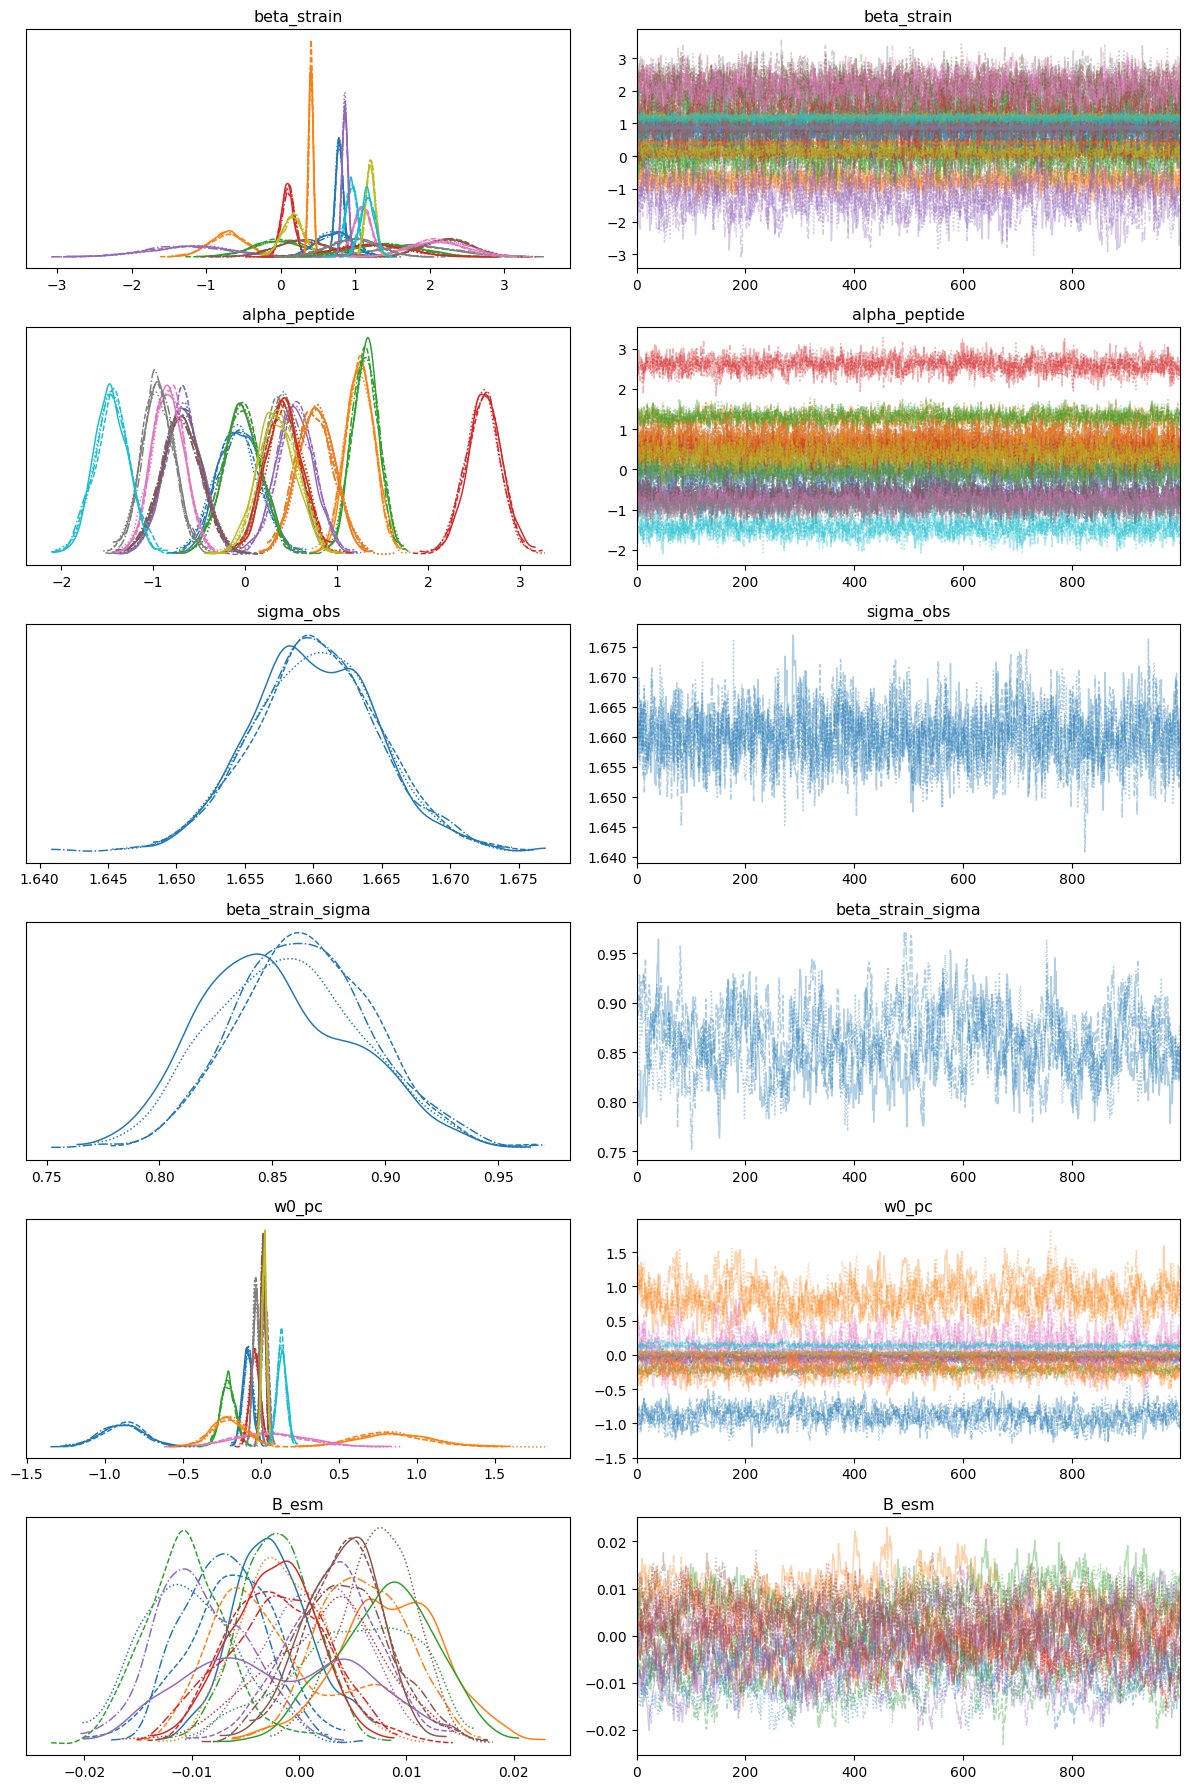

In [ ]:
idata = hpmf_model_wESMmixed_Hie.idata
peptide_list=train_df['Peptide ID'].unique()[:20]
species_list=train_df['Target Species'].unique()[:20]

# Always plot the global mean
var_names = []
coords = {}

if species_list is not None:
    var_names.append("beta_strain")
    # Convert string names to the integer indices used in the model
    coords["strain"] = [hpmf_model_wESMmixed_Hie.strain_dict[s] for s in species_list]

if peptide_list is not None:
    var_names.append("alpha_peptide")
    coords["peptide"] = [hpmf_model_wESMmixed_Hie.peptide_dict[p] for p in peptide_list]

var_names.append("sigma_obs")
var_names.append("beta_strain_sigma")
var_names.append("w0_pc")
var_names.append("B_esm")

coords["esm_interaction"] = np.arange(1)


# Plot using ArviZ
az.plot_trace(idata, var_names=var_names, coords=coords, figsize=(12, 3 * len(var_names)))
plt.tight_layout()
plt.show()

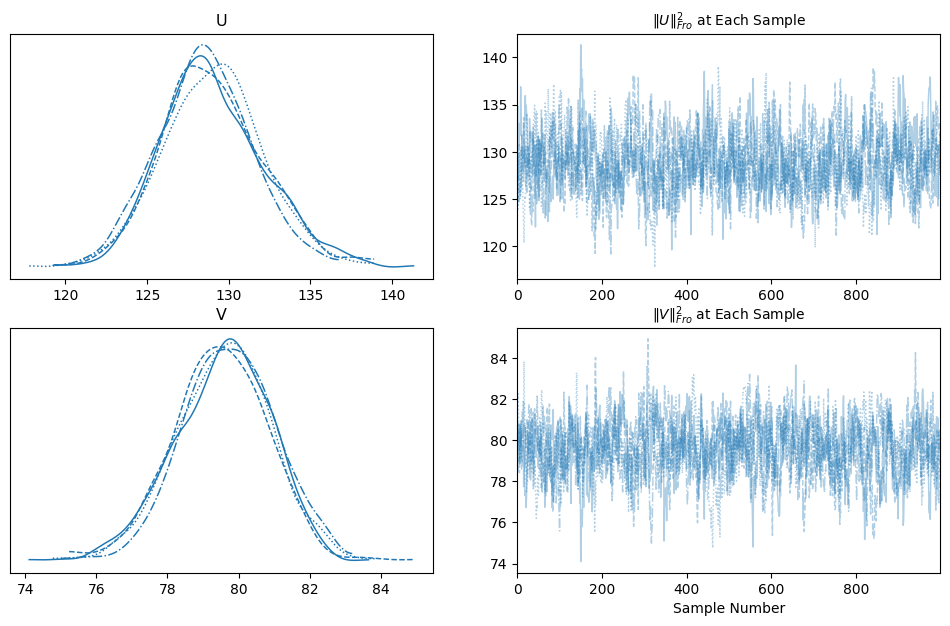

In [ ]:
hpmf_model_wESMmixed_Hie.traceplot()

### Mu Obs Posterior

In [ ]:
mu_posteriors = az.summary(hpmf_model_wESMmixed_Hie.idata,
                          var_names=["mu_obs"],
                          coords={'obs_id': np.random.choice(np.arange(75904), 10000, replace=False)}
                          )
# mu_posteriors['type'] = mu_posteriors.index.map(lambda x: x.split('[')[0])
# mu_posteriors.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)
mu_posteriors['hdi_94_size'] = mu_posteriors['hdi_97%'] - mu_posteriors['hdi_3%']
mu_posteriors['obs_id'] = mu_posteriors.index.map(lambda x: int(x.split('[')[1][:-1]))

In [ ]:
df = train_df.reset_index().join(mu_posteriors.set_index('obs_id')[['mean','hdi_94_size']])
df.rename(columns={'mean': 'HPMF_mu_post_mean', 'hdi_94_size': 'HPMF_mu_post_hdi_94_size'}, inplace=True)
df['strain_counts'] = df['Target Species'].map(train_df.groupby('Target Species').count()['Peptide ID'].to_dict())

<Axes: xlabel='HPMF_mu_post_hdi_94_size', ylabel='strain_counts'>

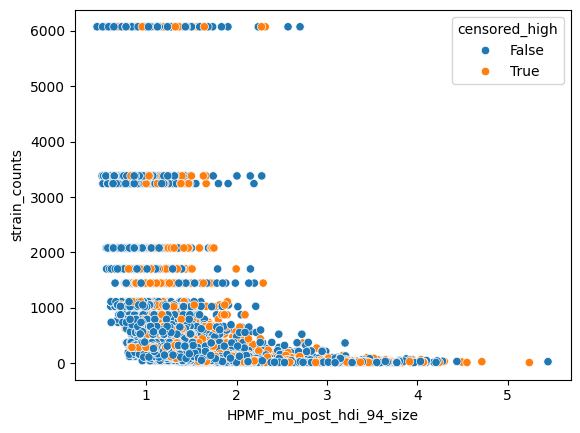

In [ ]:
sns.scatterplot(df.dropna(subset='HPMF_mu_post_mean'), x='HPMF_mu_post_hdi_94_size', y='strain_counts', hue='censored_high')

# probably take out censored_high, but it is interesting
# other things - genus/species counts ???
# can combine this plot (if I keep strain counts) and below hist plot

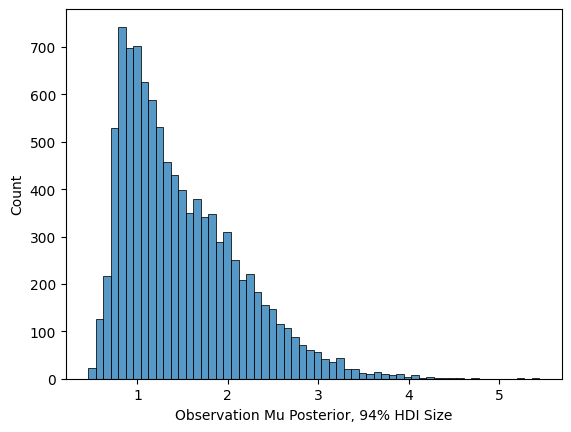

In [ ]:
ax = sns.histplot(mu_posteriors['hdi_94_size'])
plt.xlabel('Observation Mu Posterior, 94% HDI Size')
plt.savefig(os.path.join(file_path, "figures", "mu_obs_posteriors.hdi_94_size_hist.png"), bbox_inches='tight')

### Alpha Intercept Posteriors

In [ ]:
peptide_obs_counts = train_df.groupby('Peptide ID').count()['Peptide Sequence']
peptide_obs_counts.name = 'peptide_count'
peptide_obs_counts.index = peptide_obs_counts.index.map(hpmf_model_wESMmixed_Hie.peptide_dict)


In [ ]:
alpha_posteriors = az.summary(hpmf_model_wESMmixed_Hie.idata,
                          var_names=["alpha_peptide"],
                          # coords={'peptide': np.random.choice(np.arange(11987), 1000, replace=False)}
                          )
# mu_posteriors['type'] = mu_posteriors.index.map(lambda x: x.split('[')[0])
# mu_posteriors.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)
alpha_posteriors['hdi_94_size'] = alpha_posteriors['hdi_97%'] - alpha_posteriors['hdi_3%']
alpha_posteriors['peptide_id'] = alpha_posteriors.index.map(lambda x: int(x.split('[')[1][:-1]))


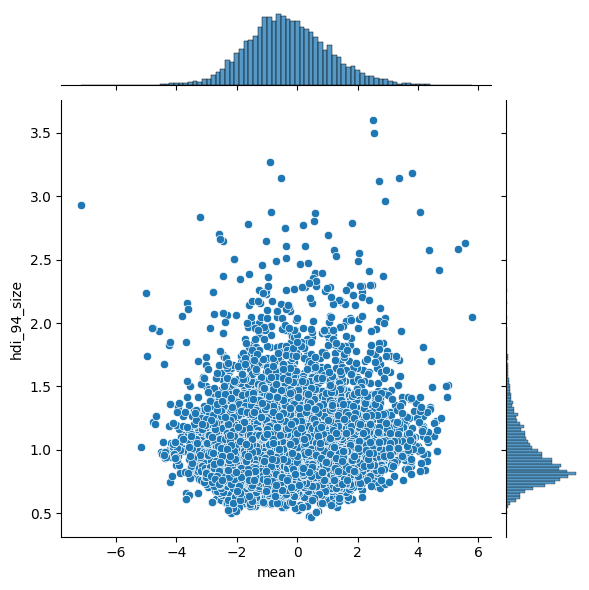

In [ ]:
tmp = alpha_posteriors.set_index('peptide_id').join(peptide_obs_counts)
sns.jointplot(tmp, x='mean', y='hdi_94_size')#, hue='peptide_count')

<Axes: xlabel='peptide_count', ylabel='Count'>

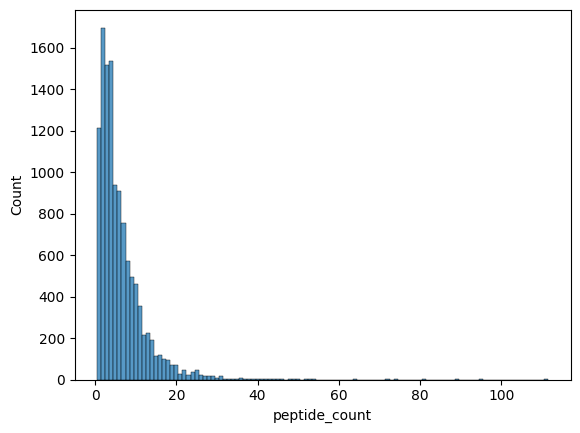

In [ ]:
sns.histplot(tmp['peptide_count'], discrete=True)

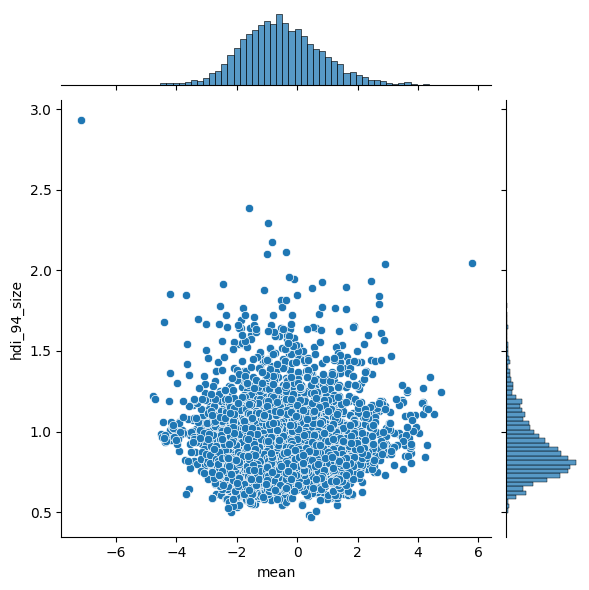

In [ ]:
sns.jointplot(tmp[tmp['peptide_count'] > 5], x='mean', y='hdi_94_size')

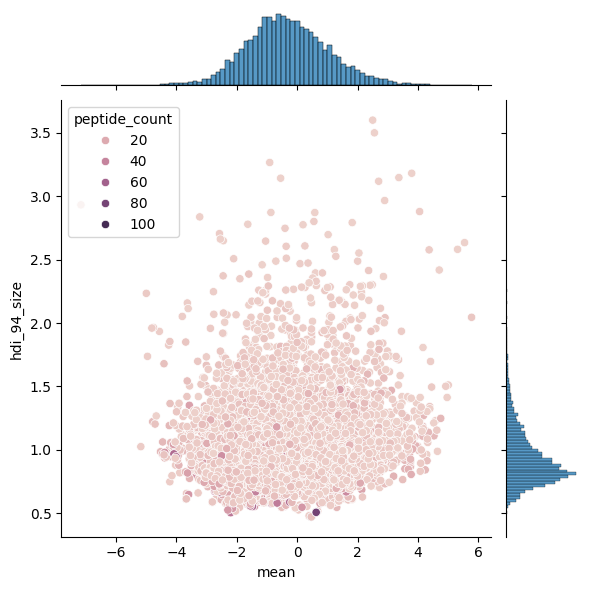

In [ ]:
sns.jointplot(tmp[tmp['peptide_count'] > 5], x='mean', y='hdi_94_size')

# 1. Initialize JointGrid without the global hue
g = sns.JointGrid(data=tmp, x='mean', y='hdi_94_size')

# 2. Add hue ONLY to the joint plot
g.plot_joint(sns.scatterplot, hue=tmp["peptide_count"])

# 3. Add un-hued plots to the marginals
g.plot_marginals(sns.histplot)

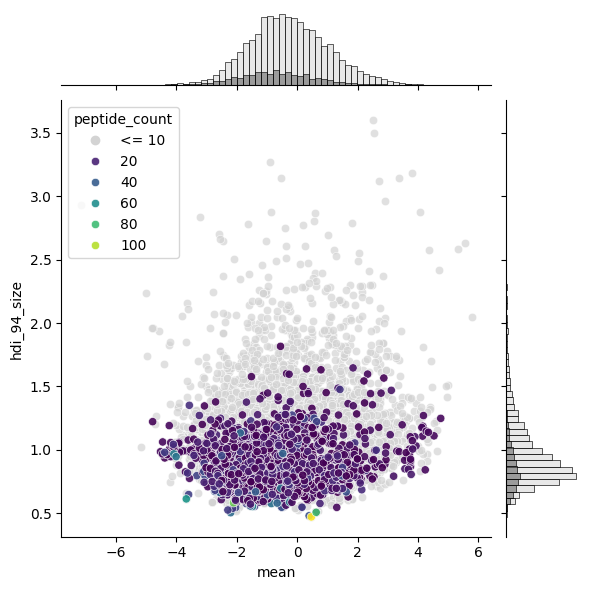

In [ ]:
g = sns.JointGrid(data=tmp, x='mean', y='hdi_94_size')

# Split data for easier referencing
threshold = 10
df_low = tmp[tmp['peptide_count'] <= threshold]
df_high = tmp[tmp['peptide_count'] > threshold]

# ==========================================
# 2. Plot the Joint axes (Scatterplots)
# ==========================================

# Background points (<= 5) in light gray
sns.scatterplot(
    data=df_low,
    x='mean',
    y='hdi_94_size',
    color='lightgray',
    alpha=0.7,
    ax=g.ax_joint,
    legend=False,
    zorder=1  # Pushes these points to the background
)

# Foreground points (> 5) with hue
sns.scatterplot(
    data=df_high,
    x='mean',
    y='hdi_94_size',
    hue='peptide_count',
    palette='viridis',  # You can change this to any color map
    alpha=0.9,
    ax=g.ax_joint,
    zorder=2  # Pulls these points to the front to make them "pop"
)

# ==========================================
# 3. Plot the Marginal axes (Histograms)
# ==========================================

# Marginals for background (<= 5)
sns.histplot(
    data=df_low, x='mean',
    color='lightgray', ax=g.ax_marg_x, alpha=0.5, binwidth=0.2
)
sns.histplot(
    data=df_low, y='hdi_94_size',
    color='lightgray', ax=g.ax_marg_y, alpha=0.5, binwidth=0.05
)

# Marginals for foreground (> 5) without hue
# (Using a solid color like dark gray or blue so it overlays cleanly)
sns.histplot(
    data=df_high, x='mean',
    color='dimgray', ax=g.ax_marg_x, alpha=0.6, binwidth=0.2
)
sns.histplot(
    data=df_high, y='hdi_94_size',
    color='dimgray', ax=g.ax_marg_y, alpha=0.6, binwidth=0.05
)

# Get the current handles and labels that seaborn created for the >5 points
handles, labels = g.ax_joint.get_legend_handles_labels()

import matplotlib.lines as mlines

# Create a custom marker handle for the <=5 points
gray_handle = mlines.Line2D(
    [], [],
    color='lightgray',
    marker='o',
    linestyle='None',
    markersize=6
)

# Insert the custom handle and label at the top of the legend lists (index 0)
handles.insert(0, gray_handle)
labels.insert(0, f'<= {threshold}')

# Redraw the legend with the updated handles and labels
g.ax_joint.legend(handles=handles, labels=labels, title='peptide_count')

<Axes: xlabel='peptide_count', ylabel='hdi_94_size'>

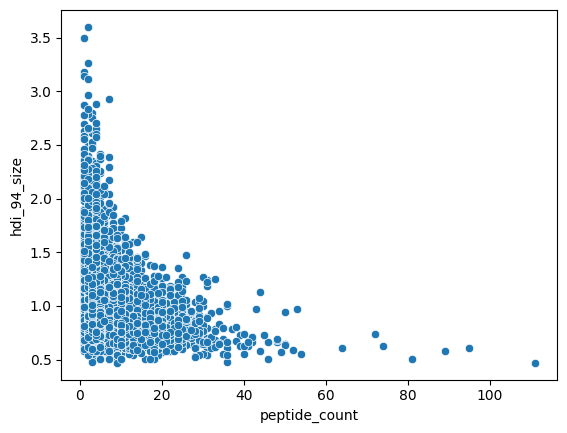

In [ ]:
sns.scatterplot(tmp, x='peptide_count', y='hdi_94_size')

In [ ]:
taxonomy_species

In [ ]:
hpmf_model_wESMmixed_Hie.idata.posterior.beta_strain.mean(("chain", "draw")).values

In [ ]:
hpmf_model_wESMmixed_Hie.idata.posterior.w0_pc.mean(("chain", "draw")).values

In [ ]:
phys_chem_norm.columns

Index(['Normalized Hydrophobic Moment', 'Normalized Hydrophobicity',
       'Net Charge', 'Isoelectric Point', 'Penetration Depth', 'Tilt Angle',
       'Disordered Conformation Propensity', 'Linear Moment',
       'Propensity to in vitro Aggregation',
       'Angle Subtended by the Hydrophobic Residues', 'Amphiphilicity Index',
       'Propensity to PPII coil'],
      dtype='object')

In [ ]:
hpmf_model_wESMmixed_Hie.idata.posterior = hpmf_model_wESMmixed_Hie.idata.posterior.assign_coords(
    phys_chem=phys_chem_norm.columns
)

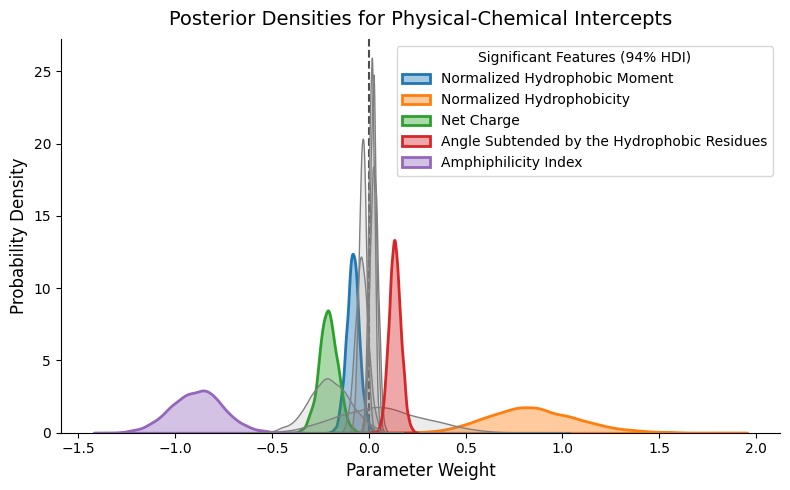

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define your custom feature names in the exact order they appear in your data
feature_names = phys_chem_norm.columns

plt.figure(figsize=(8, 5))

# 2. Extract the posterior samples and calculate the 94% HDI
w0_pc_post = hpmf_model_wESMmixed_Hie.idata.posterior["w0_pc"]

# az.hdi returns an array of shape (n_features, 2) containing [lower_bound, upper_bound]
hdi_bounds = az.hdi(w0_pc_post, hdi_prob=0.94)["w0_pc"].values

# Set up a color palette for the significant features
palette = sns.color_palette("tab10", n_colors=len(feature_names))
color_idx = 0  # Counter to assign distinct colors only to significant features

# 3. Loop through each feature and plot conditionally
for i, feature in enumerate(feature_names):
    # Flatten the chains and draws for the i-th feature
    feature_draws = w0_pc_post.isel(phys_chem=i).values.flatten()

    # Extract the HDI bounds for this specific feature
    lower_bound = hdi_bounds[i, 0]
    upper_bound = hdi_bounds[i, 1]

    # Check if 0 falls strictly inside the interval
    if lower_bound < 0 < upper_bound:
        # NOT SIGNIFICANT: Color gray, drop from legend using label="_nolegend_"
        sns.kdeplot(
            feature_draws,
            color="gray",
            fill=True,
            alpha=0.15,       # Make it more transparent
            linewidth=1,      # Thinner line so it recedes visually
            label="_nolegend_"
        )
    else:
        # SIGNIFICANT: Give it a vibrant color, thicker line, and add to legend
        sns.kdeplot(
            feature_draws,
            color=palette[color_idx],
            fill=True,
            alpha=0.4,
            linewidth=2,
            label=feature
        )
        color_idx += 1  # Advance the color palette for the next significant feature

# 4. Publication Formatting
plt.axvline(0, color='black', linestyle='--', alpha=0.7, zorder=0)

plt.title("Posterior Densities for Physical-Chemical Intercepts", fontsize=14, pad=10)
plt.xlabel("Parameter Weight", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)

# The legend will now only contain the features that bypassed the "_nolegend_" label
plt.legend(title="Significant Features (94% HDI)", frameon=True, loc='upper right')

sns.despine()
plt.tight_layout()

plt.savefig(os.path.join(file_path, 'figures', 'posteriors_pc_intercepts.png'), bbox_inches='tight')

plt.show()

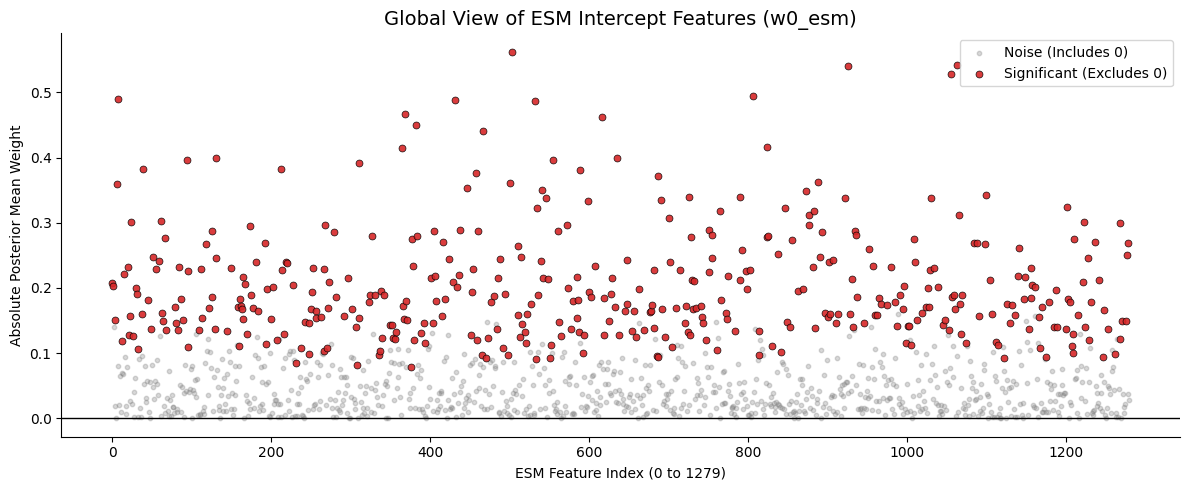

In [ ]:


# 1. Extract means and HDIs
w0_esm_post = hpmf_model_wESMmixed_Hie.idata.posterior["w0_esm"]
w0_means = w0_esm_post.mean(dim=("chain", "draw")).values
w0_hdi = az.hdi(w0_esm_post, hdi_prob=0.94)["w0_esm"].values

# 2. Determine significance (does 94% HDI exclude 0?)
is_significant = (w0_hdi[:, 0] > 0) | (w0_hdi[:, 1] < 0)

plt.figure(figsize=(12, 5))

# Plot the "noise" (non-significant features) in gray
plt.scatter(
    np.where(~is_significant)[0],
    np.abs(w0_means[~is_significant]),
    color='gray', alpha=0.3, s=10, label="Noise (Includes 0)"
)

# Plot the "signal" (significant features) in a bright color
plt.scatter(
    np.where(is_significant)[0],
    np.abs(w0_means[is_significant]),
    color='tab:red', alpha=0.9, s=25, edgecolor='black', linewidth=0.5, label="Significant (Excludes 0)"
)

plt.axhline(0, color='black', linewidth=1)
plt.title("Global View of ESM Intercept Features (w0_esm)", fontsize=14)
plt.xlabel("ESM Feature Index (0 to 1279)")
plt.ylabel("Absolute Posterior Mean Weight")
plt.legend(loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

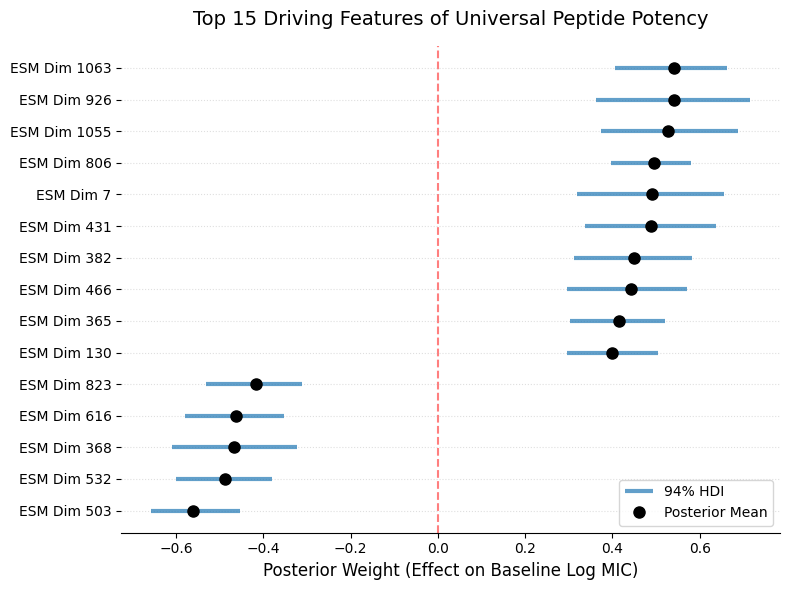

In [ ]:
import pandas as pd

# 1. Gather all significant features into a DataFrame for sorting
sig_indices = np.where(is_significant)[0]
df_sig = pd.DataFrame({
    'Feature_Index': sig_indices,
    'Mean': w0_means[sig_indices],
    'Abs_Mean': np.abs(w0_means[sig_indices]),
    'HDI_Lower': w0_hdi[sig_indices, 0],
    'HDI_Upper': w0_hdi[sig_indices, 1]
})

# 2. Sort by absolute magnitude and take the top 15
top_n = 15
df_top = df_sig.sort_values(by='Abs_Mean', ascending=False).head(top_n)

# Re-sort them by their actual Mean value (negative to positive) for a cleaner visual cascade
df_top = df_top.sort_values(by='Mean', ascending=True).reset_index(drop=True)

# 3. Create the Publication-Ready Forest Plot
plt.figure(figsize=(8, 6))

# Define Y positions
y_ticks = np.arange(len(df_top))

# Draw the 94% HDI lines
plt.hlines(
    y=y_ticks,
    xmin=df_top['HDI_Lower'],
    xmax=df_top['HDI_Upper'],
    color='tab:blue',
    linewidth=3,
    alpha=0.7,
    label="94% HDI"
)

# Plot the Posterior Means as dots
plt.plot(
    df_top['Mean'],
    y_ticks,
    'o',
    color='black',
    markersize=8,
    label="Posterior Mean"
)

# Formatting
plt.axvline(0, color='red', linestyle='--', alpha=0.5, zorder=0)

plt.yticks(y_ticks, [f"ESM Dim {int(idx)}" for idx in df_top['Feature_Index']])
plt.xlabel("Posterior Weight (Effect on Baseline Log MIC)", fontsize=12)
plt.title(f"Top {top_n} Driving Features of Universal Peptide Potency", fontsize=14, pad=15)

# Keep the legend clean and out of the way
plt.legend(loc='lower right', frameon=True)
sns.despine(left=True) # Removes the Y-axis spine for a cleaner look
plt.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Extract means and HDIs
w0_esm_post = hpmf_model_wESMmixed_Hie.idata.posterior["w0_esm"]
w0_means = w0_esm_post.mean(dim=("chain", "draw")).values
w0_hdi = az.hdi(w0_esm_post, hdi_prob=0.94)["w0_esm"].values

# 2. Determine significance (does 94% HDI exclude 0?)
esm_significant_resist = (w0_hdi[:, 0] > 0)
esm_significant_suscept = (w0_hdi[:, 1] < 0)

In [ ]:
esm_significant_resist.sum()

np.int64(213)

In [ ]:
esm_significant_suscept.sum()

np.int64(193)

In [ ]:
hpmf_model_wESMmixed_Hie.idata.posterior.w0_esm.mean(("chain", "draw")).values

### Beta Intercept Posteriors

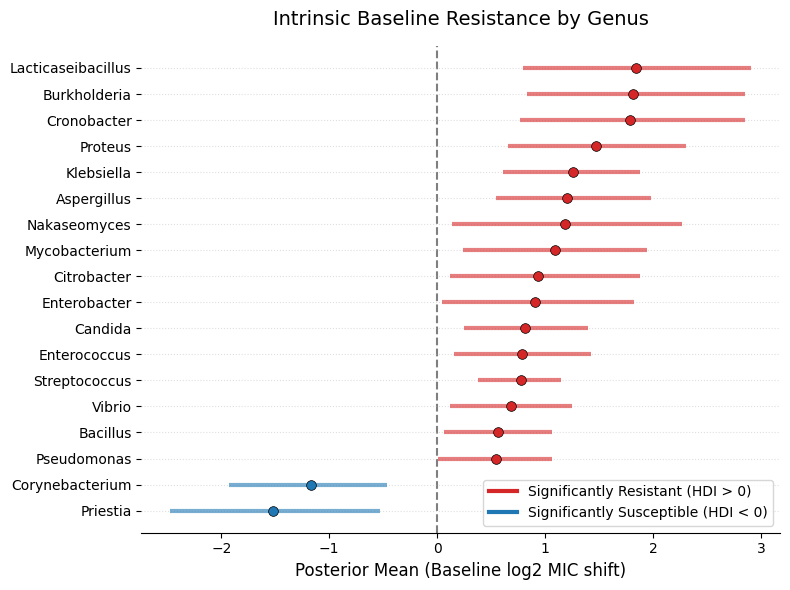

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import seaborn as sns

# 1. Extract Genus Posteriors
# (Assuming your model has a genus_dict that maps index to Genus name)
genus_names = list(hpmf_model_wESMmixed_Hie.genus_dict.keys())
beta_genus_post = hpmf_model_wESMmixed_Hie.idata.posterior["beta_genus"]

genus_means = beta_genus_post.mean(dim=("chain", "draw")).values
genus_hdi = az.hdi(beta_genus_post, hdi_prob=0.94)["beta_genus"].values

# 2. Build and Sort DataFrame
df_genus = pd.DataFrame({
    'Genus': genus_names,
    'Mean': genus_means,
    'HDI_Lower': genus_hdi[:, 0],
    'HDI_Upper': genus_hdi[:, 1]
}).sort_values(by='Mean', ascending=True).reset_index(drop=True)

# Create a boolean mask where the interval does NOT span across 0
# (i.e., both bounds are positive or both bounds are negative)
is_significant = (df_genus['HDI_Lower'] > 0) | (df_genus['HDI_Upper'] < 0)

# Filter the DataFrame to drop the neutral elements
df_genus_filtered = df_genus[is_significant].copy()

# Re-sort and re-index so the plotting positions look clean and sequential
df_genus_filtered = df_genus_filtered.sort_values(by='Mean', ascending=True).reset_index(drop=True)

# 3. Plotting
plt.figure(figsize=(8, max(6, len(df_genus_filtered) * 0.3))) # Dynamic height
y_ticks = np.arange(len(df_genus_filtered))

for i, row in df_genus_filtered.iterrows():
    # Color logic: Red if significantly hard, Blue if soft, Gray if neutral
    if row['HDI_Lower'] > 0:
        color = 'tab:red'
    elif row['HDI_Upper'] < 0:
        color = 'tab:blue'
    else:
        color = 'gray'

    # Draw HDI and Mean
    plt.hlines(y=i, xmin=row['HDI_Lower'], xmax=row['HDI_Upper'], color=color, linewidth=3, alpha=0.6)
    plt.plot(row['Mean'], i, 'o', color=color, markersize=7, markeredgecolor='black', markeredgewidth=0.5)

# Formatting
plt.axvline(0, color='black', linestyle='--', alpha=0.5, zorder=0)
plt.yticks(y_ticks, df_genus_filtered['Genus'], fontsize=10)
plt.xlabel("Posterior Mean (Baseline log2 MIC shift)", fontsize=12)
plt.title("Intrinsic Baseline Resistance by Genus", fontsize=14, pad=15)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='tab:red', lw=3, label='Significantly Resistant (HDI > 0)'),
    # Line2D([0], [0], color='gray', lw=3, label='Average (HDI includes 0)'),
    Line2D([0], [0], color='tab:blue', lw=3, label='Significantly Susceptible (HDI < 0)')
]
plt.legend(handles=legend_elements, loc='lower right', frameon=True)

sns.despine(left=True)
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(file_path, 'figures', 'genus_resistance.png'), bbox_inches='tight')

plt.show()

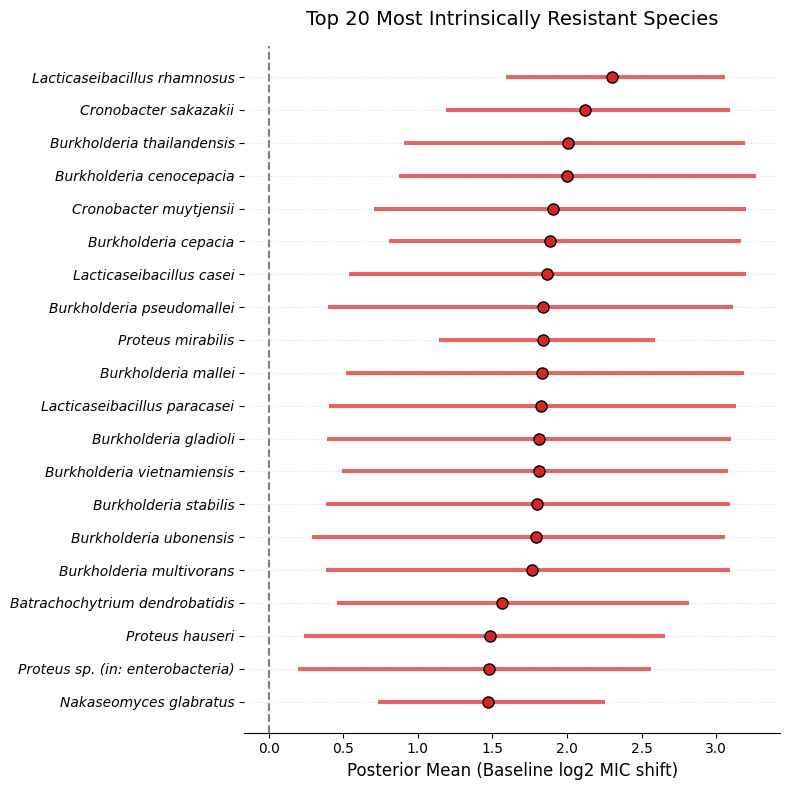

In [ ]:
# 1. Extract Species Posteriors
species_names = list(hpmf_model_wESMmixed_Hie.species_dict.keys())
beta_species_post = hpmf_model_wESMmixed_Hie.idata.posterior["beta_species"]

species_means = beta_species_post.mean(dim=("chain", "draw")).values
species_hdi = az.hdi(beta_species_post, hdi_prob=0.94)["beta_species"].values

# 2. Build DataFrame and Filter to Top 20
df_species = pd.DataFrame({
    'Species': species_names,
    'Mean': species_means,
    'HDI_Lower': species_hdi[:, 0],
    'HDI_Upper': species_hdi[:, 1]
})

# Sort descending to get the hardest, then take top 20
df_hardest_species = df_species.sort_values(by='Mean', ascending=False).head(20)

# Re-sort ascending just for the plot (so the hardest is at the very top of the graph)
df_hardest_species = df_hardest_species.sort_values(by='Mean', ascending=True).reset_index(drop=True)

# 3. Plotting
plt.figure(figsize=(8, 8))
y_ticks = np.arange(len(df_hardest_species))

# We can just color them all red here since we are specifically looking at the hardest
plt.hlines(y=y_ticks, xmin=df_hardest_species['HDI_Lower'], xmax=df_hardest_species['HDI_Upper'],
           color='tab:red', linewidth=3, alpha=0.7)
plt.plot(df_hardest_species['Mean'], y_ticks, 'o', color='tab:red', markersize=8, markeredgecolor='black')

# Formatting
plt.axvline(0, color='black', linestyle='--', alpha=0.5, zorder=0)
plt.yticks(y_ticks, df_hardest_species['Species'], fontsize=10, style='italic') # Italicize species names!
plt.xlabel("Posterior Mean (Baseline log2 MIC shift)", fontsize=12)
plt.title("Top 20 Most Intrinsically Resistant Species", fontsize=14, pad=15)

sns.despine(left=True)
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
species_names = list(hpmf_model_wESMmixed_Hie.species_dict.keys())
beta_species_post = hpmf_model_wESMmixed_Hie.idata.posterior["beta_species"]

species_means = beta_species_post.mean(dim=("chain", "draw")).values
species_hdi = az.hdi(beta_species_post, hdi_prob=0.94)["beta_species"].values

# 2. Build DataFrame and Filter to Top 20
df_species = pd.DataFrame({
    'Species': species_names,
    'Mean': species_means,
    'HDI_Lower': species_hdi[:, 0],
    'HDI_Upper': species_hdi[:, 1]
}).set_index('Species')

In [ ]:
df_species[df_species['HDI_Lower'] > 0].shape

(76, 3)

In [ ]:
df_species.shape

(791, 3)

In [ ]:
df_species[df_species.index.str.contains('Enterobacter')]

,Mean,HDI_Lower,HDI_Upper
Species,,,
Enterobacter cloacae,1.037636,0.468894,1.569160
Enterobacter sp.,0.997055,-0.185993,2.000099
Enterobacter asburiae,0.906895,-0.426931,2.150538
Enterobacter mori,0.886607,-0.433470,2.140411
Enterobacter ludwigii,0.898830,-0.291517,2.186361
Enterobacter kobei,0.917992,-0.313952,2.140434
Enterobacter hormaechei,0.895467,-0.342325,2.130917
Enterobacter spp. NCIM 5392,-0.124702,-1.986606,1.960298


In [ ]:
eskapee = ['Enterococcus faecium',
         'Staphylococcus aureus',
         'Klebsiella pneumoniae',
         'Acinetobacter baumannii',
         'Pseudomonas aeruginosa',
          'Enterobacter sp.',
          'Escherichia coli']

In [ ]:

df_species.loc[eskapee]

,Mean,HDI_Lower,HDI_Upper
Species,,,
Enterococcus faecium,0.825224,0.362846,1.293252
Staphylococcus aureus,0.700544,0.518242,0.870111
Klebsiella pneumoniae,1.458265,1.112203,1.781614
Acinetobacter baumannii,0.527683,0.198452,0.851310
Pseudomonas aeruginosa,1.059224,0.854121,1.270709
Enterobacter sp.,0.997055,-0.185993,2.000099
Escherichia coli,0.233065,0.081968,0.398548


In [ ]:
strain_names = list(hpmf_model_wESMmixed_Hie.strain_dict.keys())
beta_strains_post = hpmf_model_wESMmixed_Hie.idata.posterior["beta_strain"]

strains_means = beta_strains_post.mean(dim=("chain", "draw")).values
strains_hdi = az.hdi(beta_strains_post, hdi_prob=0.94)["beta_strain"].values

# 2. Build DataFrame and Filter to Top 20
df_strains = pd.DataFrame({
    'Strains': strain_names,
    'Mean': strains_means,
    'HDI_Lower': strains_hdi[:, 0],
    'HDI_Upper': strains_hdi[:, 1]
}).set_index('Strains')

In [ ]:
df_strains[df_strains['HDI_Lower'] > 0].shape

(432, 3)

### ESKAPEE Predictions

In [ ]:
eskapee_og = most_species_df['Peptide ID'].drop_duplicates()

# 3. Duplicate each row to match the length of the rotating list
eskapee_test = eskapee_og.loc[eskapee_og.index.repeat(len(eskapee))].reset_index(drop=True).to_frame()

# 4. Fill the new column by tiling the list across the expanded dataframe length
eskapee_test.loc[:, 'Target Species'] = np.tile(eskapee, len(eskapee_og))



In [ ]:
eskapee_pred = hpmf_model_wESMmixed_Hie.predict_new_peptides(eskapee_test, return_full_posterior=True)
eskapee_pred_means = eskapee_pred.mean(("chain", "draw")).MIC_obs.values


Output()

In [ ]:
eskapee_test['pred_mean'] = eskapee_pred_means

<Axes: xlabel='pred_mean', ylabel='Count'>

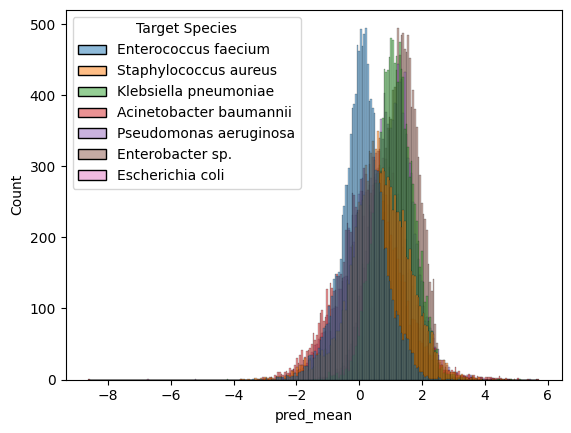

In [ ]:
sns.histplot(eskapee_test, x='pred_mean', hue='Target Species')

In [ ]:
eskapee_test.groupby('Target Species').min()

,Peptide ID,pred_mean
Target Species,,
Acinetobacter baumannii,8,-8.636561
Enterobacter sp.,8,-1.432016
Enterococcus faecium,8,-3.374166
Escherichia coli,8,-6.727708
Klebsiella pneumoniae,8,-4.179269
Pseudomonas aeruginosa,8,-5.218620
Staphylococcus aureus,8,-3.744778


In [ ]:
eskapee_pred

<xarray.Dataset> Size: 3GB
Dimensions:  (chain: 4, draw: 1000, obs_id: 88319)
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
  * obs_id   (obs_id) int64 707kB 0 1 2 3 4 5 ... 88314 88315 88316 88317 88318
Data variables:
    MIC_obs  (chain, draw, obs_id) float64 3GB 1.543 -1.037 ... 2.116 -1.62
Attributes:
    created_at:                 2026-06-09T02:13:54.721131+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.5

In [ ]:
eskapee_test_hdi = az.hdi(eskapee_pred, hdi_prob=0.94)["MIC_obs"].values

In [ ]:
eskapee_test[['hdi_bound_low','hdi_bound_high']] = eskapee_test_hdi


In [ ]:
eskapee_test[eskapee_test['hdi_bound_high'] < 0]

,Peptide ID,Target Species,pred_mean,hdi_bound_low,hdi_bound_high
12211,7444,Acinetobacter baumannii,-3.755575,-7.135030,-0.401101
41737,11074,Acinetobacter baumannii,-8.636561,-13.072796,-4.487600
41738,11074,Pseudomonas aeruginosa,-5.218620,-9.233894,-1.366461
41740,11074,Escherichia coli,-6.727708,-10.616141,-2.384241
43611,11655,Staphylococcus aureus,-3.726180,-7.386515,-0.136197
43653,11661,Staphylococcus aureus,-3.670351,-7.310119,-0.269836
43667,11663,Staphylococcus aureus,-3.744778,-7.126016,-0.006577


### HDI Coverage - Calibration

In [ ]:
hpmf_model_wESMmixed_Hie.get_HDI_coverage(hold_peptides_test, hdi_prob=0.50)

Output()

np.float64(40.42553191489361)

In [ ]:
def get_HDI_coverage(self, test_df, hdi_prob=0.94, new_peptide_method="knn", k=10):
    # 1. Get the FULL matrix of posterior predictions
    # Shape will be (chains, draws, n_test_observations)
    posterior_preds_xr = self.predict_new_peptides(test_df, return_full_posterior=True, new_peptide_method=new_peptide_method, k=k)

    if type(hdi_prob) is list:
        coverage_out = {}
        for hdi in hdi_prob:
            # 2. Calculate the HDI for every single test observation
            # az.hdi returns an array of shape (n_test_observations, 2) containing [lower_bound, upper_bound]
            hdi_bounds = az.hdi(posterior_preds_xr, hdi_prob=hdi)["MIC_obs"].values

            # 3. Check how many true values fall inside their respective HDIs
            true_values = test_df["mic"].values
            in_interval = (true_values >= hdi_bounds[:, 0]) & (true_values <= hdi_bounds[:, 1])

            coverage_pct = in_interval.mean() * 100
            coverage_out[hdi] = coverage_pct
        return coverage_out
    else:
        # 2. Calculate the HDI for every single test observation
        # az.hdi returns an array of shape (n_test_observations, 2) containing [lower_bound, upper_bound]
        hdi_bounds = az.hdi(posterior_preds_xr, hdi_prob=hdi_prob)["MIC_obs"].values

        # 3. Check how many true values fall inside their respective HDIs
        true_values = test_df["mic"].values
        in_interval = (true_values >= hdi_bounds[:, 0]) & (true_values <= hdi_bounds[:, 1])

        coverage_pct = in_interval.mean() * 100

        return coverage_pct

In [ ]:
target_hdi = [0.2, 0.35, 0.5, 0.6, 0.7, 0.8, 0.9, 0.94]
calibration_vals = get_HDI_coverage(hpmf_model_wESMmixed_Hie, hold_peptides_test, hdi_prob=target_hdi)

Output()

Text(0, 0.5, 'Actual HDI %')

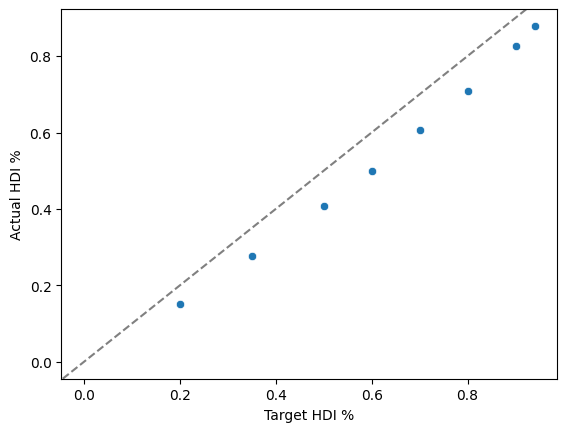

In [ ]:
target_hdi = [0.2, 0.35, 0.5, 0.6, 0.7, 0.8, 0.9, 0.94]

actual_hdi = [calibration_vals[t]/100 for t in target_hdi]

ax = sns.scatterplot(x=target_hdi,y=actual_hdi)
ax.axline((0, 0), slope=1, color="gray", linestyle="--", linewidth=1.5)
ax.set_xlabel('Target HDI %')
ax.set_ylabel('Actual HDI %')
# add x=y lineo9

## Without Hierarchical

In [ ]:
hpmf_model_wESMmixed = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), taxonomy_species,
                                 dim=6, horseshoe_u=False, horseshoe_intercept=True, non_centered=True,
                                 hierarchical=False, anchor_pc=True,
                                 esm_intercept=esm_input.copy(), esm_interaction=esm_pca_input.copy(),
                                 sigma_obs_sigma=3, beta_sigma=2,
                                 esm_active_num=15, slab_scale = 4.0)

idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_wESMmixed.6_1.gt_10_species.nc"))
hpmf_model_wESMmixed.idata = idata

In [ ]:

train_ESMmixed_out, test_ESMmixed_out, ESMmixed_performance = hpmf_model_wESMmixed.full_evaluation(hold_peptides_test)
ESMmixed_performance

In [ ]:
strains = list(hpmf_model_wESM_Hie.strain_dict.keys())
tmp_df = taxonomy_species.drop_duplicates().set_index('Target Species').loc[strains]

beta_strain_H = hpmf_model_wESM_Hie.idata.posterior["beta_strain"].mean(dim=("chain","draw")).values
beta_strain_NoH = hpmf_model_wESM.idata.posterior["beta_strain"].mean(dim=("chain","draw")).values

counts = most_species_df['Target Species'].value_counts()
tmp_df['beta_strain_Hierarchy'] = beta_strain_H
tmp_df['beta_strain_Original'] = beta_strain_NoH
tmp_df['obs_counts'] = counts.loc[strains]

species_sums = tmp_df.groupby('species')['obs_counts'].sum()
species_sums.name = 'species_counts'
tmp_df = tmp_df.merge(species_sums, right_index=True, left_on='species')
genus_sums = tmp_df.groupby('genus')['obs_counts'].sum()
genus_sums.name = 'genus_counts'
tmp_df = tmp_df.merge(genus_sums, right_index=True, left_on='genus')

stacked_df = tmp_df.melt(
    id_vars=['obs_counts', 'genus'],
    value_vars=['beta_strain_Original', 'beta_strain_Hierarchy'],
    var_name='model',
    value_name='beta_strain_means'
)
sns.scatterplot(stacked_df, x='obs_counts', y='beta_strain_means', hue='model')

In [ ]:
# 1. Identify the top 4 most abundant genera to keep the plot legible
top_genera = tmp_df['genus'].value_counts().nlargest(2).index
subset_df = tmp_df[tmp_df['genus'].isin(top_genera)]

plt.figure(figsize=(10, 8))
colors = sns.color_palette("tab10", n_colors=len(top_genera))
genus_color_map = dict(zip(top_genera, colors))

for _, row in subset_df.iterrows():
    color = genus_color_map[row['genus']]
    x_start = row['beta_strain_Original']
    x_end = row['beta_strain_Hierarchy']

    # Draw the line connecting Original to Hierarchy
    plt.plot([x_start, x_end], [row['obs_counts'], row['obs_counts']],
             color=color, alpha=0.4, linewidth=1)

    # Plot the endpoints
    plt.scatter(x_start, row['obs_counts'], color=color, alpha=0.3, s=15, marker='o') # Original
    plt.scatter(x_end, row['obs_counts'], color=color, alpha=0.9, s=20, marker='>')   # Hierarchy

plt.yscale('log')
plt.title("Strain Intercept Movement (Original → Hierarchical)")
plt.xlabel("Beta Strain Mean")
plt.ylabel("Observation Counts (Log Scale)")

# Custom legend
handles = [plt.Line2D([0], [0], color=color, marker='>', linestyle='-', label=genus)
           for genus, color in genus_color_map.items()]
plt.legend(handles=handles, title="Genus")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Linear (w/o Interaction)

In [ ]:
hpmf_model_wESM_Hie_Linear = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), taxonomy_species,
                                        horseshoe_u=False, horseshoe_intercept=True, non_centered=True,
                                        hierarchical=True, linreg=True, esm_intercept=esm_input.copy(),
                                        sigma_obs_sigma=3, beta_sigma=2,
                                        esm_active_num=15, slab_scale = 4.0)

idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_wESM_Hie_Linear.5_25.gt_10_species.nc"))
hpmf_model_wESM_Hie_Linear.idata = idata

sample: 100%|██████████| 2500/2500 [23:09<00:00,  1.80it/s]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[2,1000,349].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [ ]:
train_linear_out, test_linear_out, linear_performance = hpmf_model_wESM_Hie_Linear.full_evaluation(hold_peptides_test)
linear_performance

Output()

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Output()

Output()

Output()

{'rmse_train': np.float64(1.8048019248307554),
 'rmse_test': np.float64(2.407013944950052),
 'elpd_train': np.float64(-154652.61914492646),
 'elpd_test': np.float64(-9218.682332484163)}

In [ ]:
pep_features = az.summary(hpmf_model_wESM_Hie_Linear.idata,
                          var_names=["w0_esm", "w0_pc"],
                          coords={'esm_intercept': np.random.choice(np.arange(1280), 100, replace=False)})
pep_features['type'] = pep_features.index.map(lambda x: x.split('[')[0])
pep_features.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)

/tmp/ipykernel_5138/3466549412.py:5: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pep_features.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)


ess_bulk                 ess_tail                    r_hat           
type       w0_esm       w0_pc       w0_esm        w0_pc      w0_esm      w0_pc
count   100.00000   12.000000   100.000000    12.000000  100.000000  12.000000
mean    626.24000  426.750000  1003.560000   831.750000    1.001600   1.005000
std     182.82564  116.706411   409.229933   259.600436    0.003949   0.005222
min     264.00000  195.000000   121.000000   310.000000    1.000000   1.000000
25%     487.50000  399.500000   661.500000   796.000000    1.000000   1.000000
50%     623.00000  460.000000  1106.000000   902.000000    1.000000   1.005000
75%     740.50000  513.000000  1341.000000  1009.000000    1.000000   1.010000
max    1068.00000  544.000000  1692.000000  1067.000000    1.020000   1.010000

In [ ]:
intercepts = az.summary(hpmf_model_wESM_Hie_Linear.idata,
                        var_names=["alpha_peptide", "beta_genus", "beta_species", "beta_strain"],
                        coords={'peptide': np.random.choice(hpmf_model_wESM_Hie_Linear.model.coords["peptide"], 100, replace=False),
                                'genus': np.random.choice(hpmf_model_wESM_Hie_Linear.model.coords["genus"], 10, replace=False),
                                'species': np.random.choice(hpmf_model_wESM_Hie_Linear.model.coords["species"], 30, replace=False),
                                'strain': np.random.choice(hpmf_model_wESM_Hie_Linear.model.coords["strain"], 30, replace=False)})
intercepts['type'] = intercepts.index.map(lambda x: x.split('[')[0])
intercepts.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)

/tmp/ipykernel_5138/1946482760.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  intercepts.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)


ess_bulk                                           ess_tail  \
type  alpha_peptide beta_genus beta_species  beta_strain alpha_peptide   
count    100.000000   10.00000    30.000000    30.000000    100.000000   
mean    1030.370000  687.20000   482.566667  1365.366667   1566.040000   
std      192.667278   78.10648   218.264263   622.889179    201.011328   
min      550.000000  542.00000   169.000000   717.000000   1073.000000   
25%      900.500000  670.75000   307.250000   924.750000   1413.250000   
50%     1022.000000  697.00000   423.500000  1054.000000   1604.000000   
75%     1147.500000  716.00000   688.500000  1863.750000   1721.000000   
max     1542.000000  804.00000   847.000000  3058.000000   1940.000000   

                                                     r_hat             \
type    beta_genus beta_species  beta_strain alpha_peptide beta_genus   
count    10.000000     30.00000    30.000000      100.0000  10.000000   
mean    931.900000    784.20000  1313.000000        1.0001   1.002000   
std     157.369664    239.47261   235.494637        0.0010   0.004216   
min     738.000000    336.00000   864.000000        1.0000   1.000000   
25%     789.750000    623.75000  1149.500000        1.0000   1.000000   
50%     915.000000    802.50000  1327.000000        1.0000   1.000000   
75%    1038.750000    960.50000  1439.500000        1.0000   1.000000   
max    1208.000000   1267.00000  1789.000000        1.0100   1.010000   

                                
type  beta_species beta_strain  
count    30.000000        30.0  
mean      1.005000         1.0  
std       0.007311         0.0  
min       1.000000         1.0  
25%       1.000000         1.0  
50%       1.000000         1.0  
75%       1.010000         1.0  
max       1.030000         1.0

In [ ]:
az.summary(hpmf_model_wESM_Hie_Linear.idata,
           var_names=["sigma_obs", "beta_genus_sigma", "beta_species_sigma", "beta_strain_sigma", "w0_pc_sigma"])[['ess_bulk','ess_tail','r_hat']]

,ess_bulk,ess_tail,r_hat
sigma_obs,1060.0,1368.0,1.00
beta_genus_sigma,72.0,132.0,1.02
beta_species_sigma,23.0,133.0,1.08
beta_strain_sigma,111.0,231.0,1.04
w0_pc_sigma,307.0,594.0,1.01


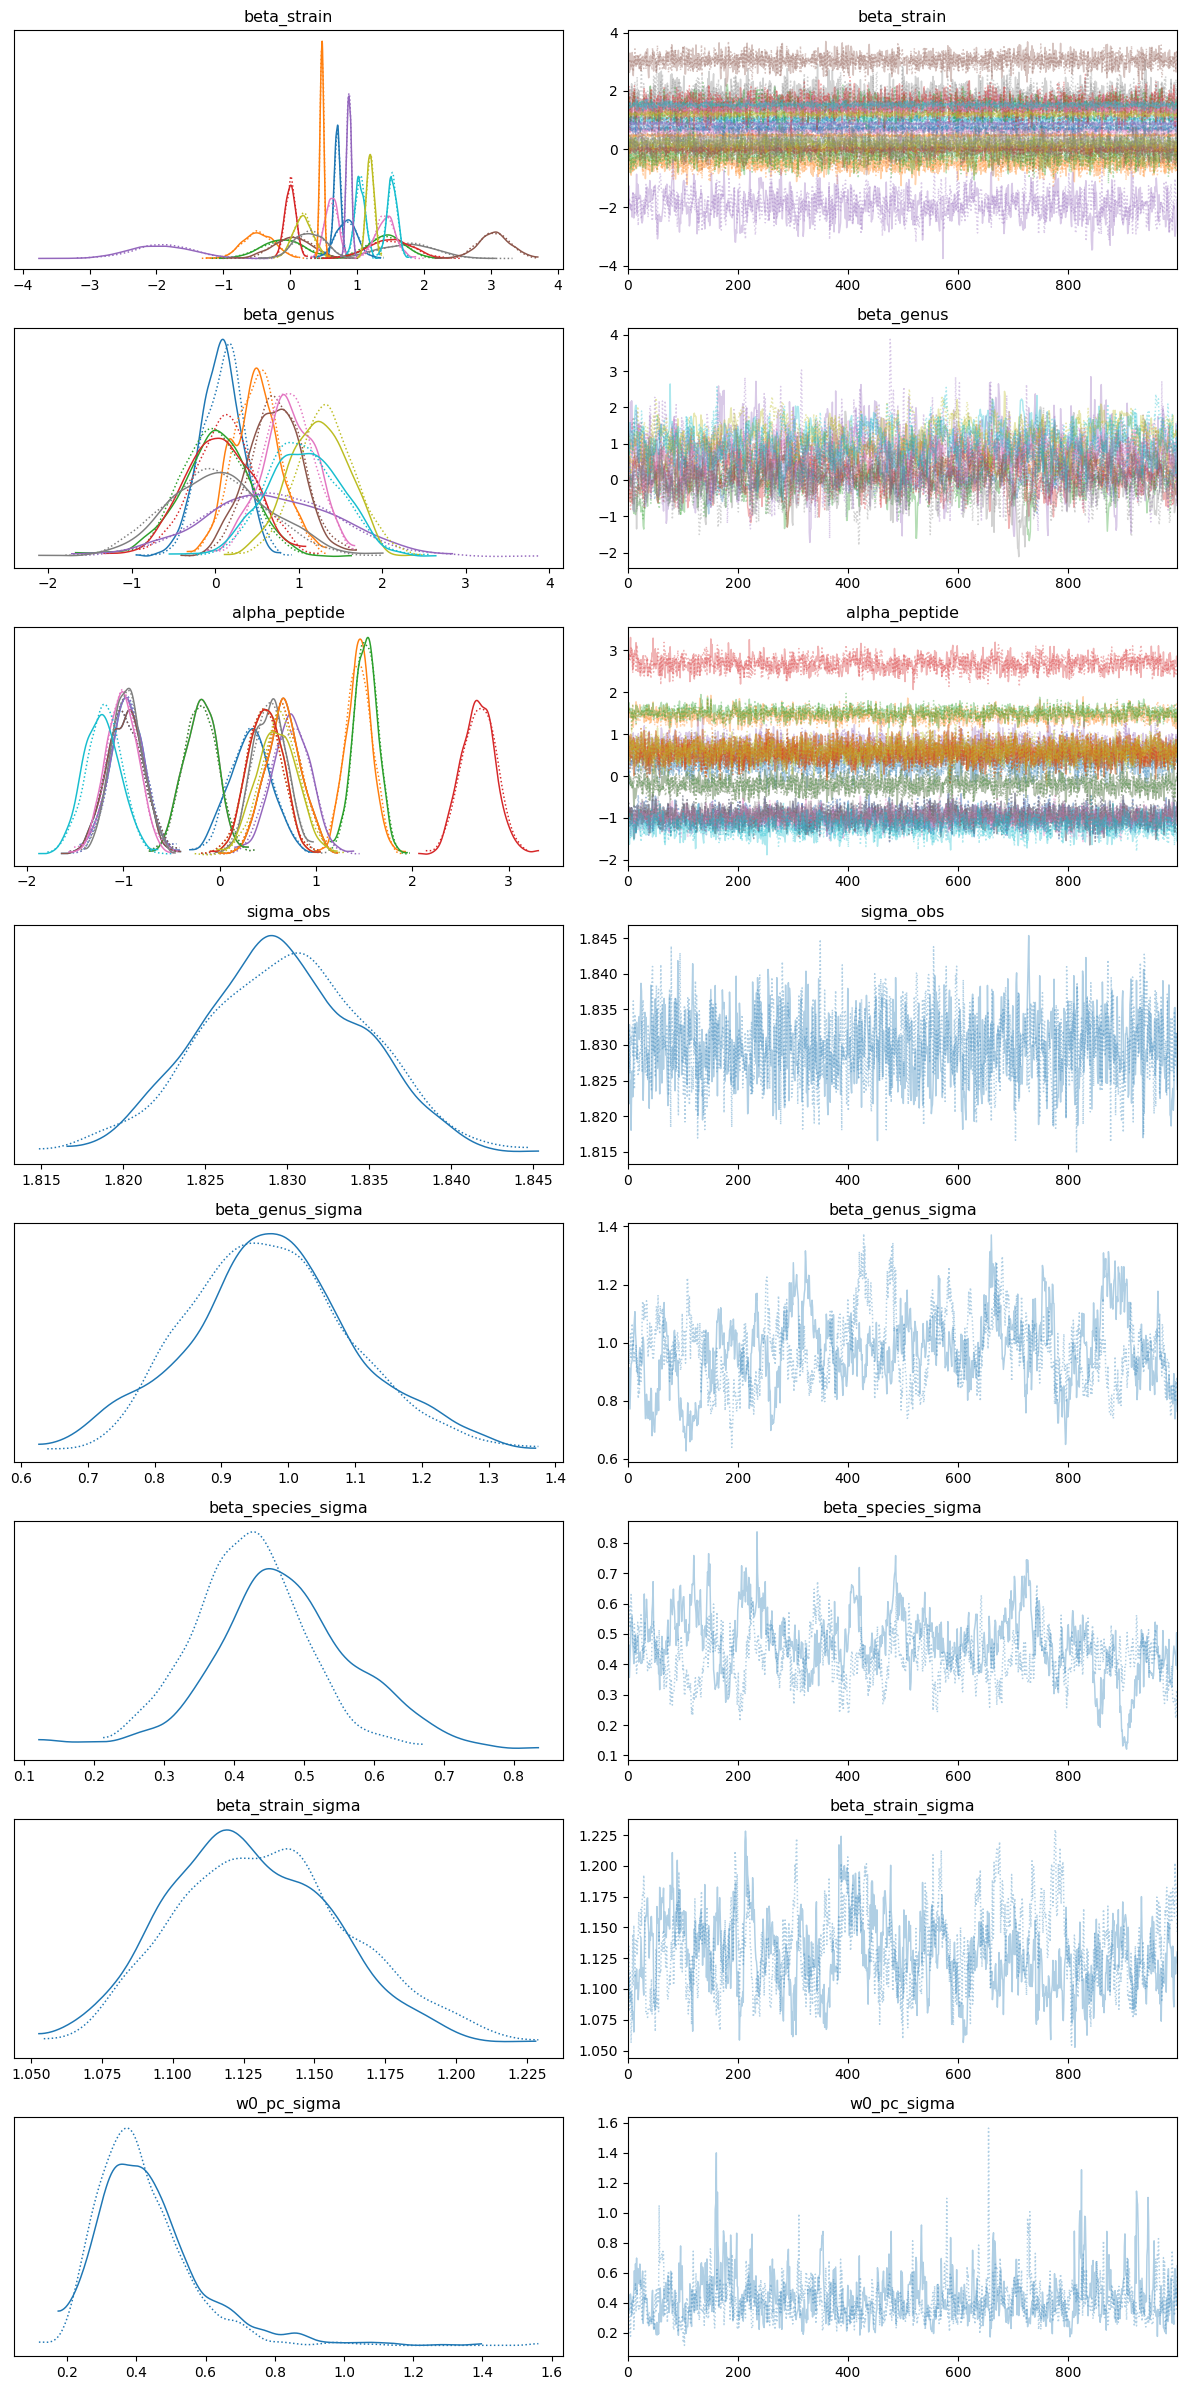

In [ ]:
idata = hpmf_model_wESM_Hie_Linear.idata
peptide_list=train_df['Peptide ID'].unique()[:20]
species_list=train_df['Target Species'].unique()[:20]
genus_list=taxonomy_species[taxonomy_species['Target Species'].isin(train_df['Target Species'])]['genus'].unique()[:10]

# Always plot the global mean
var_names = []
coords = {}

if species_list is not None:
    var_names.append("beta_strain")
    # Convert string names to the integer indices used in the model
    coords["strain"] = [hpmf_model_wESM_Hie_Linear.strain_dict[s] for s in species_list]
if genus_list is not None:
    var_names.append("beta_genus")
    # Convert string names to the integer indices used in the model
    coords["genus"] = [hpmf_model_wESM_Hie_Linear.genus_dict[s] for s in genus_list]

if peptide_list is not None:
    var_names.append("alpha_peptide")
    coords["peptide"] = [hpmf_model_wESM_Hie_Linear.peptide_dict[p] for p in peptide_list]

var_names.append("sigma_obs")
var_names.append("beta_genus_sigma")
var_names.append("beta_species_sigma")
var_names.append("beta_strain_sigma")
var_names.append("w0_pc_sigma")

# Plot using ArviZ
az.plot_trace(idata, var_names=var_names, coords=coords, figsize=(12, 3 * len(var_names)))
plt.tight_layout()
plt.show()

## Without ESM

In [ ]:
hpmf_model_noESM_Hie = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), taxonomy_species,
                                  dim=6, horseshoe_u=False, horseshoe_intercept=False, non_centered=True,
                                 hierarchical=True, anchor_pc=True,
                                 esm_intercept=None, esm_interaction=None,
                                 sigma_obs_sigma=3, beta_sigma=2)

idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_noESM_Hie.anchor_pc.5_25.gt_10_species.nc"))
hpmf_model_noESM_Hie.idata = idata

/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(


In [ ]:
train_noESM_Hie_out, test_noESM_Hie_out, noESM_Hie_performance = hpmf_model_noESM_Hie.full_evaluation(hold_peptides_test)
noESM_Hie_performance

{'rmse_train': np.float64(1.9435045768708776),
 'rmse_test': np.float64(2.188729864841133),
 'elpd_train': np.float64(-159320.9196803198),
 'elpd_test': np.float64(-8704.337363382188)}

In [ ]:
pep_features = az.summary(hpmf_model_noESM_Hie.idata,
                          var_names=["w0_pc", "B_pc_raw", "B_pc_anchors"])
pep_features['type'] = pep_features.index.map(lambda x: x.split('[')[0])
pep_features.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)

/tmp/ipykernel_2796/3983000590.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pep_features.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)


ess_bulk                               ess_tail               \
type  B_pc_anchors     B_pc_raw        w0_pc B_pc_anchors     B_pc_raw   
count     6.000000    72.000000    12.000000     6.000000    72.000000   
mean     25.000000   319.402778   973.416667    63.500000   168.513889   
std       6.033241  1039.554572   211.207980    16.208023   407.083858   
min      18.000000     4.000000   707.000000    45.000000    12.000000   
25%      19.500000     6.000000   827.750000    48.750000    31.000000   
50%      26.000000    11.000000   875.000000    65.500000    47.000000   
75%      29.500000    16.250000  1089.500000    77.750000    70.500000   
max      32.000000  4532.000000  1360.000000    80.000000  1587.000000   

                          r_hat                   
type         w0_pc B_pc_anchors   B_pc_raw w0_pc  
count    12.000000     6.000000  72.000000  12.0  
mean   1296.583333     1.073333   1.184167   1.0  
std     188.034068     0.021602   0.114286   0.0  
min     954.000000     1.040000   1.000000   1.0  
25%    1266.250000     1.062500   1.107500   1.0  
50%    1296.000000     1.075000   1.170000   1.0  
75%    1370.500000     1.087500   1.272500   1.0  
max    1637.000000     1.100000   1.410000   1.0

In [ ]:
hpmf_model_noESM_Hie.idata.posterior.B_pc_anchors.mean(("chain", "draw")).values

array([0.17669026, 0.55954201, 0.23902624, 0.26932127, 0.09964311,
       0.10291749])

In [ ]:
intercepts_interactions = az.summary(hpmf_model_noESM_Hie.idata,
                        var_names=["alpha_peptide", "beta_genus", "beta_species", "beta_strain",
                                   "U", "V_genus", "V_species", "V_strains"],
                        coords={'peptide': np.random.choice(hpmf_model_noESM_Hie.model.coords["peptide"], 100, replace=False),
                                'genus': np.random.choice(hpmf_model_noESM_Hie.model.coords["genus"], 10, replace=False),
                                'species': np.random.choice(hpmf_model_noESM_Hie.model.coords["species"], 30, replace=False),
                                'strain': np.random.choice(hpmf_model_noESM_Hie.model.coords["strain"], 30, replace=False)})
intercepts_interactions['type'] = intercepts_interactions.index.map(lambda x: x.split('[')[0])
intercepts_interactions.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)

/tmp/ipykernel_2796/3574533758.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  intercepts_interactions.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)


ess_bulk                                                       \
type            U      V_genus    V_species    V_strains alpha_peptide   
count  600.000000    60.000000   180.000000   180.000000    100.000000   
mean    12.293333  3484.700000  2346.666667   125.394444   1161.060000   
std      7.679773  1276.947875  1701.613927   299.776835    259.913382   
min      3.000000     6.000000    13.000000     4.000000    669.000000   
25%      6.000000  3282.250000   455.500000    19.000000    923.000000   
50%     10.000000  3771.500000  2592.000000    42.500000   1177.000000   
75%     17.000000  4191.500000  3855.000000    87.750000   1361.750000   
max     51.000000  5098.000000  5387.000000  2243.000000   1812.000000   

                                                ess_tail               ...  \
type    beta_genus beta_species  beta_strain           U      V_genus  ...   
count    10.000000     30.00000    30.000000  600.000000    60.000000  ...   
mean   2688.100000   2245.90000  2856.533333   40.211667  1222.233333  ...   
std     870.943862    868.15275   577.676782   21.185094   351.581481  ...   
min     747.000000    391.00000  2058.000000   11.000000    95.000000  ...   
25%    2264.500000   1607.50000  2521.250000   23.000000  1215.500000  ...   
50%    2980.000000   2020.00000  2763.500000   35.000000  1312.000000  ...   
75%    3170.500000   2954.25000  3030.500000   54.000000  1356.500000  ...   
max    3846.000000   3901.00000  4979.000000  117.000000  1655.000000  ...   

                                      r_hat                         \
type  beta_species  beta_strain           U    V_genus   V_species   
count    30.000000    30.000000  600.000000  60.000000  180.000000   
mean   1381.000000  1591.200000    1.201883   1.010333    1.008278   
std     201.415508   161.964108    0.130380   0.035174    0.017619   
min     739.000000  1203.000000    1.010000   1.000000    1.000000   
25%    1296.750000  1517.750000    1.100000   1.000000    1.000000   
50%    1361.500000  1600.000000    1.170000   1.000000    1.000000   
75%    1493.750000  1690.250000    1.270000   1.010000    1.010000   
max    1768.000000  1863.000000    1.710000   1.260000    1.100000   

                                                                     
type    V_strains alpha_peptide beta_genus beta_species beta_strain  
count  180.000000         100.0  10.000000    30.000000   30.000000  
mean     1.059111           1.0   1.002000     1.001000    1.000333  
std      0.066880           0.0   0.004216     0.003051    0.001826  
min      1.000000           1.0   1.000000     1.000000    1.000000  
25%      1.020000           1.0   1.000000     1.000000    1.000000  
50%      1.040000           1.0   1.000000     1.000000    1.000000  
75%      1.072500           1.0   1.000000     1.000000    1.000000  
max      1.380000           1.0   1.010000     1.010000    1.010000  

[8 rows x 24 columns]

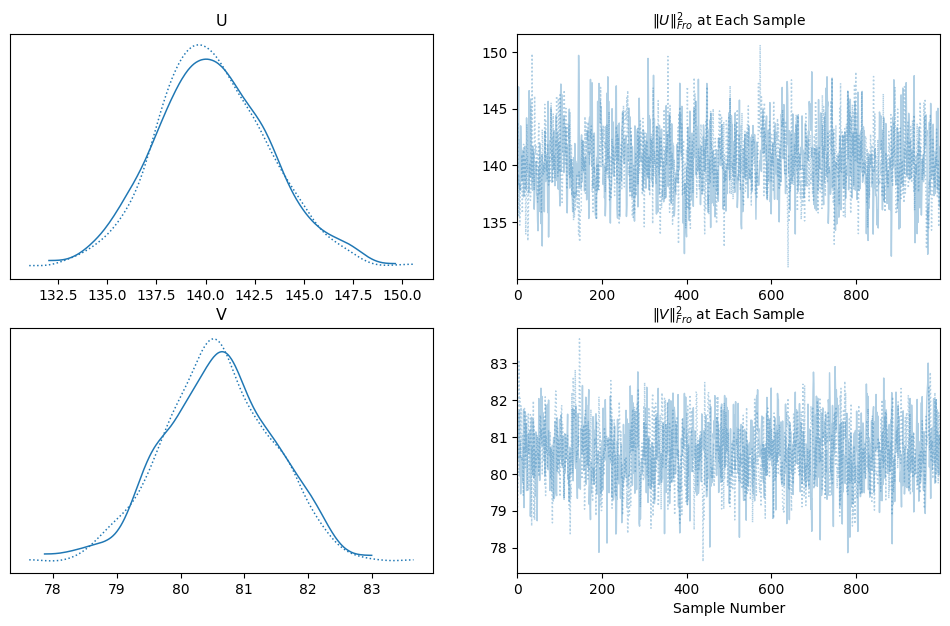

In [ ]:
hpmf_model_noESM_Hie.traceplot()

## Random Effects (w/o Hybrid PMF)

In [ ]:
hpmf_model_wESM_Hie_RandomEffects = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), taxonomy_species,
                                              horseshoe_u=False, horseshoe_intercept=True, non_centered=True, random_effects=True,
                                              hierarchical=True, esm_intercept=esm_input.copy(), esm_interaction=None,
                                              sigma_obs_sigma=3, beta_sigma=2,
                                              esm_active_num=15, slab_scale = 4.0)

idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_wESM_Hie_RandomEffects.5_25.gt_10_species.nc"))
hpmf_model_wESM_Hie_RandomEffects.idata = idata

/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(


In [ ]:
train_random_effects_out, test_random_effects_out, random_effects_performance = hpmf_model_wESM_Hie_RandomEffects.full_evaluation(hold_peptides_test)
random_effects_performance

In [ ]:
# Using KNN=10
train_random_effects_out, test_random_effects_out, random_effects_performance = hpmf_model_wESM_Hie_RandomEffects.full_evaluation(hold_peptides_test, compute_elpd=False)
random_effects_performance

Output()

Output()

{'rmse_train': np.float64(0.7702589715790762),
 'rmse': np.float64(2.411818487159316)}

In [ ]:
train_random_effects_out, test_random_effects_out, random_effects_performance = hpmf_model_wESM_Hie_RandomEffects.full_evaluation(hold_peptides_test, new_peptide_method='mean', compute_elpd=False)
random_effects_performance

Output()

Output()

{'rmse_train': np.float64(0.7702103074265604),
 'rmse_test': np.float64(2.409778512699736)}

In [ ]:
train_random_effects_out, test_random_effects_out, random_effects_performance = hpmf_model_wESM_Hie_RandomEffects.full_evaluation(hold_peptides_test, k=1, compute_elpd=False)
random_effects_performance

Output()

Output()

{'rmse_train': np.float64(0.7702575531792089),
 'rmse_test': np.float64(2.4138541870731043)}

Does not change the results at all. I am a little skeptical of this (I should make sure the KNN and gen_U code is working), but it could just mean that the interaction terms aren't really learning anything useful. It is overfitting on the learned U's but they don't actually carry that much useful information in general.

It would be most interesting to see how the cross-species predictions do (but I actually filter most of these out of the dataset by only doing the peptide_hold_out set).

In [ ]:
pep_features = az.summary(hpmf_model_wESM_Hie_RandomEffects.idata,
                          var_names=["w0_esm", "w0_pc"],
                          # coords={'esm_intercept': np.random.choice(np.arange(1280), 100, replace=False),
                          #         'esm_interaction': np.random.choice(np.arange(62), 40, replace=False)}
                          )
pep_features['type'] = pep_features.index.map(lambda x: x.split('[')[0])
pep_features.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)

/tmp/ipykernel_9421/4132841013.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pep_features.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)


ess_bulk                 ess_tail                    r_hat  \
type        w0_esm       w0_pc       w0_esm       w0_pc       w0_esm   
count  1280.000000   12.000000  1280.000000   12.000000  1280.000000   
mean     92.754688   62.083333   191.559375  120.916667     1.029742   
std      42.133551   21.377381    82.954680   34.487042     0.028037   
min       7.000000   30.000000    17.000000   51.000000     1.000000   
25%      59.000000   48.000000   131.000000   96.750000     1.010000   
50%      93.000000   62.000000   183.500000  130.500000     1.020000   
75%     124.000000   72.250000   242.000000  141.750000     1.040000   
max     210.000000  102.000000   519.000000  170.000000     1.250000   

                  
type       w0_pc  
count  12.000000  
mean    1.028333  
std     0.015275  
min     1.020000  
25%     1.020000  
50%     1.020000  
75%     1.032500  
max     1.070000

In [ ]:
intercepts_interactions = az.summary(hpmf_model_wESM_Hie_RandomEffects.idata,
                        var_names=["alpha_peptide", "beta_genus", "beta_species", "beta_strain",
                                   "U", "V_genus", "V_species", "V_strains"],
                        coords={'peptide': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["peptide"], 1000, replace=False),
                                'genus': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["genus"], 50, replace=False),
                                'species': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["species"], 200, replace=False),
                                'strain': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["strain"], 500, replace=False)}
                                     )
intercepts_interactions['type'] = intercepts_interactions.index.map(lambda x: x.split('[')[0])
intercepts_interactions.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)

/tmp/ipykernel_9421/2719165225.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  intercepts_interactions.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)


ess_bulk                                                      \
type              U     V_genus    V_species    V_strains alpha_peptide   
count  10000.000000  500.000000  2000.000000  5000.000000   1000.000000   
mean      83.533300  100.262000    83.312000    11.763200     74.937000   
std       59.530364   70.964648    75.395384    22.069657     25.808858   
min        3.000000    2.000000     2.000000     2.000000     10.000000   
25%       19.000000   18.000000     4.000000     3.000000     58.000000   
50%       90.000000  115.000000    88.500000     3.000000     76.000000   
75%      133.000000  161.000000   155.000000     8.000000     92.000000   
max      248.000000  238.000000   259.000000   215.000000    155.000000   

                                               ess_tail              ...  \
type   beta_genus beta_species beta_strain            U     V_genus  ...   
count   50.000000   200.000000  500.000000  10000.00000  500.000000  ...   
mean   126.700000   121.090000  122.502000    226.56890  228.120000  ...   
std     49.771826    47.594201   51.323779     93.83473  127.019359  ...   
min     33.000000    11.000000   16.000000     13.00000   12.000000  ...   
25%     81.250000    87.750000   90.000000    163.00000  119.250000  ...   
50%    134.000000   125.500000  118.000000    230.00000  251.000000  ...   
75%    163.500000   158.250000  148.000000    291.00000  324.000000  ...   
max    218.000000   224.000000  506.000000    539.00000  536.000000  ...   

                                        r_hat                           \
type  beta_species  beta_strain             U     V_genus    V_species   
count   200.000000   500.000000  10000.000000  500.000000  2000.000000   
mean    247.685000   301.698000      1.088935    1.141820     1.259750   
std      97.854398   125.106603      0.129288    0.273962     0.368414   
min      21.000000    60.000000      1.000000    1.000000     1.000000   
25%     176.500000   215.000000      1.020000    1.010000     1.010000   
50%     241.000000   278.500000      1.040000    1.020000     1.040000   
75%     309.000000   360.000000      1.100000    1.102500     1.422500   
max     533.000000  1041.000000      1.980000    2.560000     2.860000   

                                                                      
type     V_strains alpha_peptide beta_genus beta_species beta_strain  
count  5000.000000   1000.000000  50.000000   200.000000  500.000000  
mean      1.546880      1.029850   1.019400     1.024350    1.019960  
std       0.343791      0.023542   0.015039     0.023027    0.018118  
min       1.000000      1.000000   1.000000     1.000000    1.000000  
25%       1.200000      1.010000   1.010000     1.010000    1.010000  
50%       1.600000      1.020000   1.015000     1.020000    1.010000  
75%       1.840000      1.040000   1.027500     1.030000    1.030000  
max       2.980000      1.150000   1.070000     1.160000    1.120000  

[8 rows x 24 columns]

In [ ]:
az.summary(hpmf_model_wESM_Hie_RandomEffects.idata,
           var_names=["sigma_obs", "beta_genus_sigma", "beta_species_sigma", "beta_strain_sigma",
                      "sig_genus", "sig_species", "sig_strain", "w0_pc_sigma", "sigma_u"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_obs,1.017,0.004,1.009,1.025,0.001,0.000,63.0,217.0,1.03
beta_genus_sigma,1.010,0.111,0.807,1.215,0.022,0.009,25.0,56.0,1.07
beta_species_sigma,0.463,0.074,0.331,0.602,0.015,0.005,24.0,85.0,1.03
beta_strain_sigma,0.764,0.024,0.720,0.810,0.004,0.002,37.0,97.0,1.03
sig_genus,0.864,0.009,0.848,0.880,0.002,0.001,24.0,129.0,1.10
sig_species,0.196,0.030,0.138,0.247,0.013,0.002,6.0,58.0,1.28
sig_strain,0.462,0.013,0.437,0.488,0.002,0.001,44.0,101.0,1.04
w0_pc_sigma,0.143,0.061,0.057,0.257,0.010,0.006,35.0,131.0,1.02
sigma_u,0.492,0.011,0.472,0.512,0.002,0.001,51.0,91.0,1.01


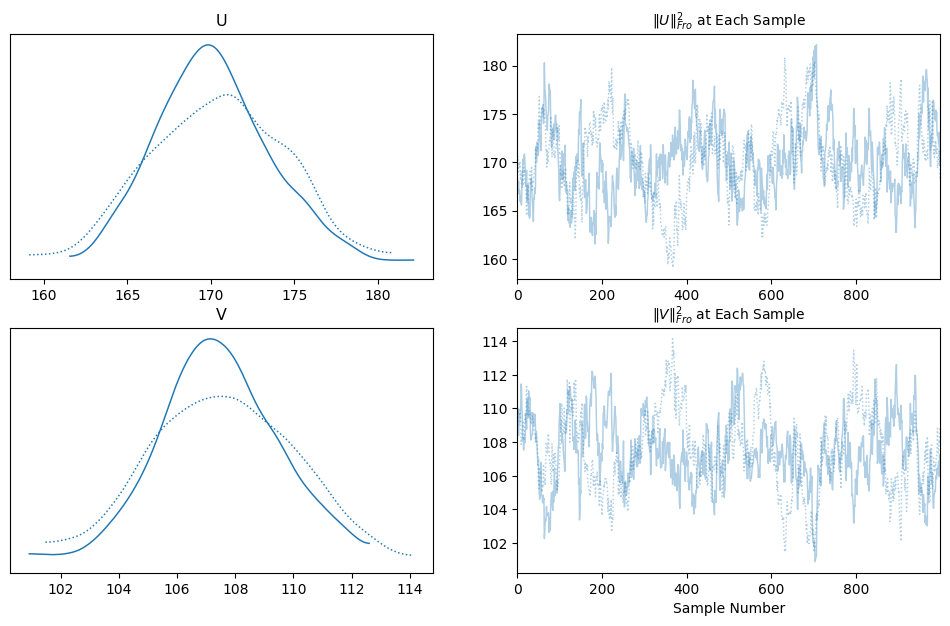

In [ ]:
hpmf_model_wESM_Hie_RandomEffects.traceplot()

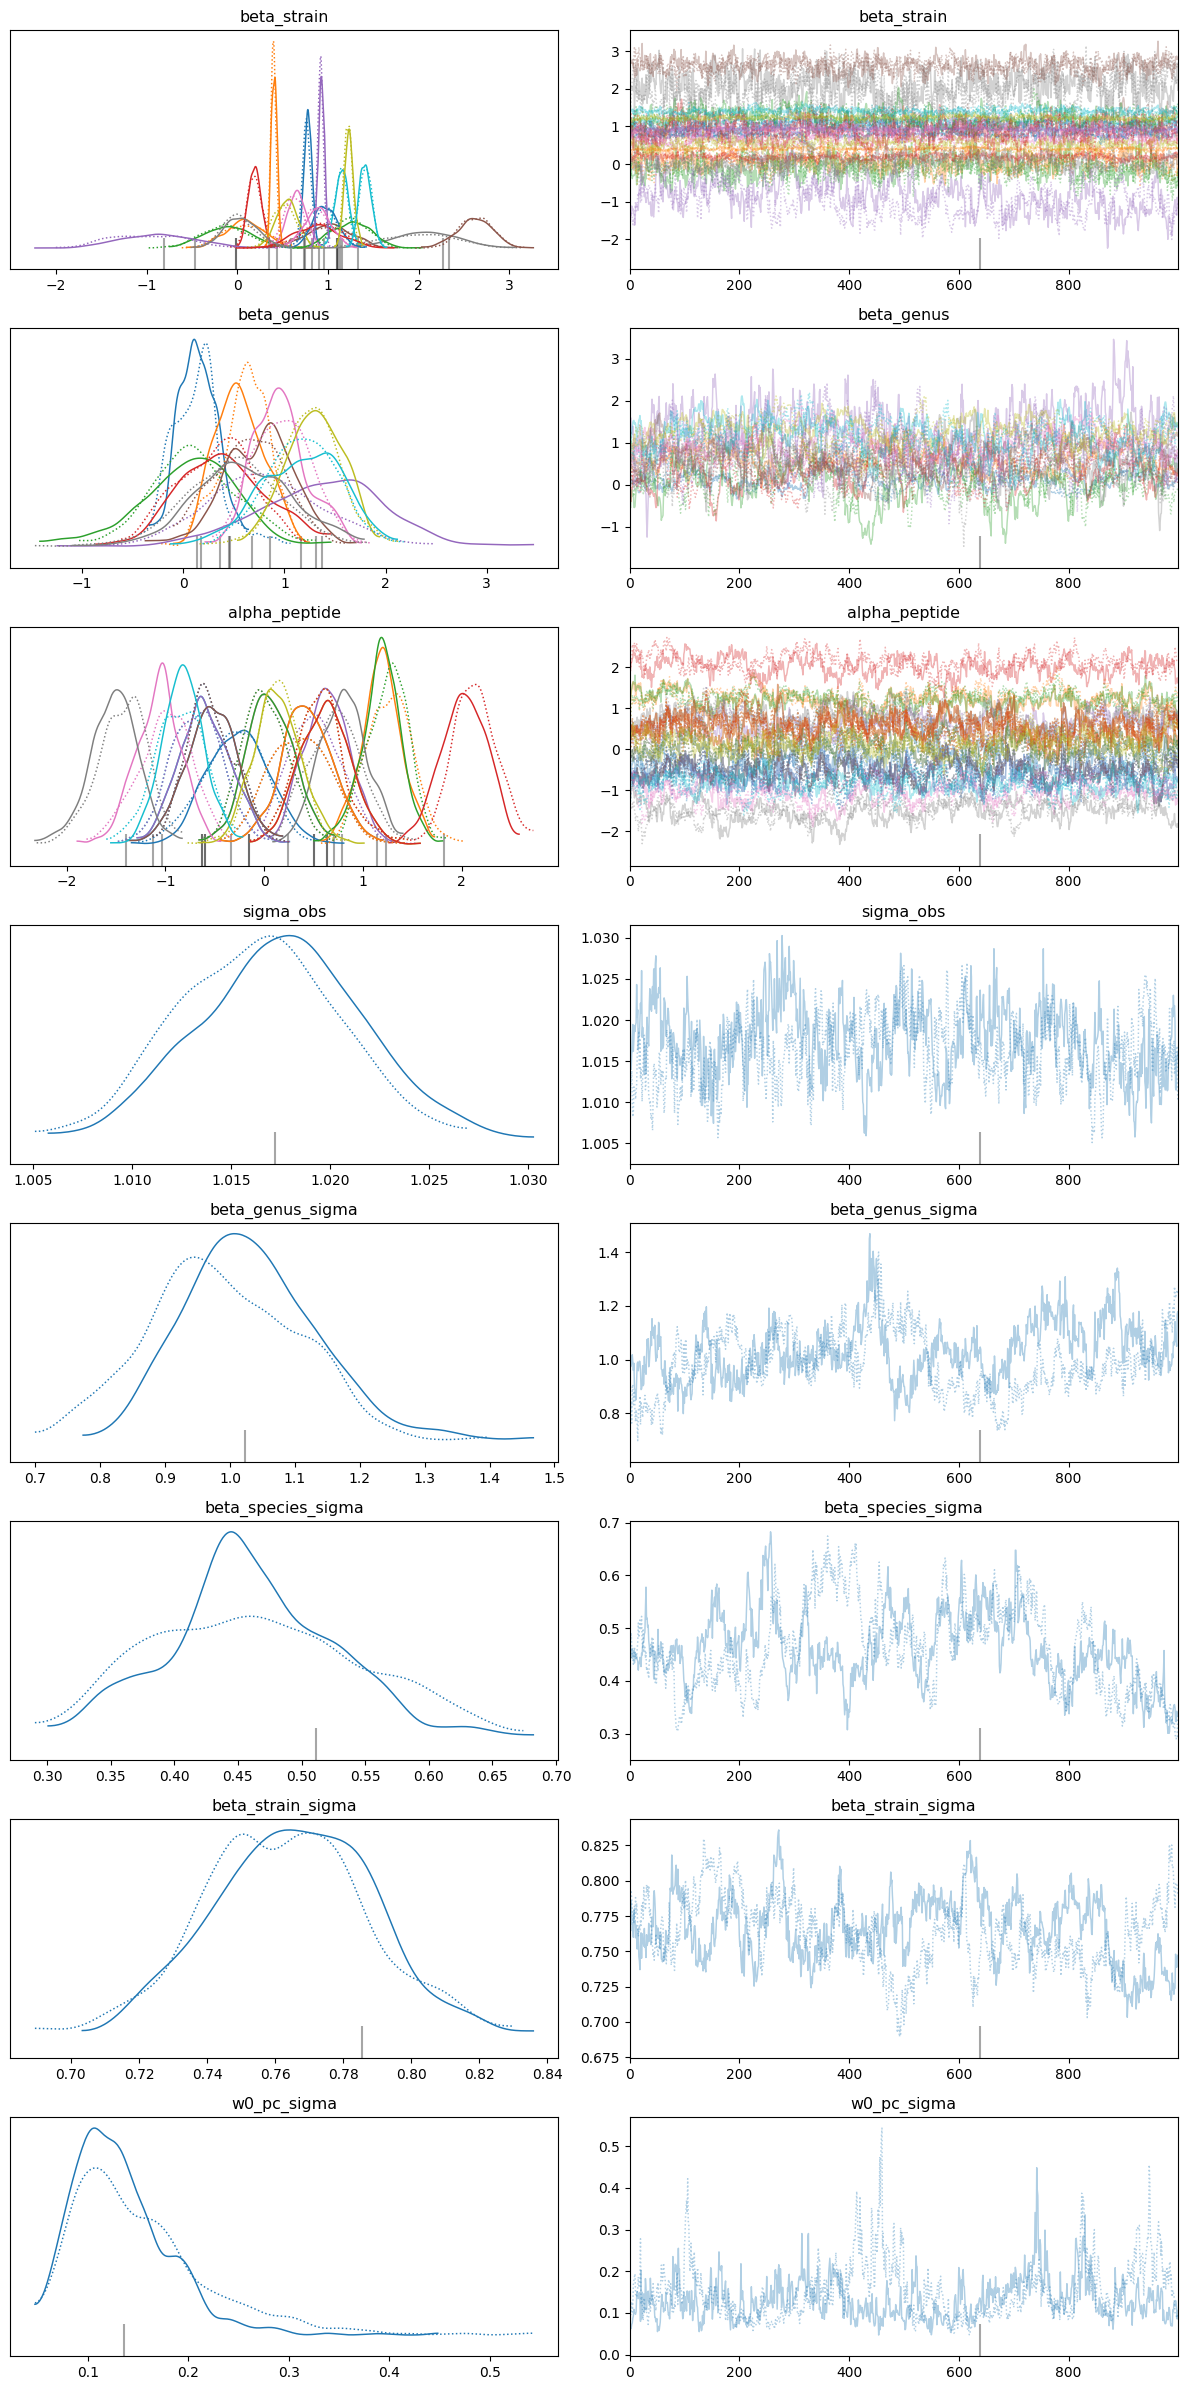

In [ ]:
idata = hpmf_model_wESM_Hie_RandomEffects.idata
peptide_list=train_df['Peptide ID'].unique()[:20]
species_list=train_df['Target Species'].unique()[:20]
genus_list=taxonomy_species[taxonomy_species['Target Species'].isin(train_df['Target Species'])]['genus'].unique()[:10]

# Always plot the global mean
var_names = []
coords = {}

if species_list is not None:
    var_names.append("beta_strain")
    # Convert string names to the integer indices used in the model
    coords["strain"] = [hpmf_model_wESM_Hie_RandomEffects.strain_dict[s] for s in species_list]
if genus_list is not None:
    var_names.append("beta_genus")
    # Convert string names to the integer indices used in the model
    coords["genus"] = [hpmf_model_wESM_Hie_RandomEffects.genus_dict[s] for s in genus_list]

if peptide_list is not None:
    var_names.append("alpha_peptide")
    coords["peptide"] = [hpmf_model_wESM_Hie_RandomEffects.peptide_dict[p] for p in peptide_list]

var_names.append("sigma_obs")
var_names.append("beta_genus_sigma")
var_names.append("beta_species_sigma")
var_names.append("beta_strain_sigma")
var_names.append("w0_pc_sigma")

# Plot using ArviZ
az.plot_trace(idata, var_names=var_names, coords=coords, figsize=(12, 3 * len(var_names)))
plt.tight_layout()
plt.show()

In [ ]:
print(hpmf_model_wESMmixed_Hie.strain_dict)
# You can also convert it to a pandas Series or DataFrame for better viewing if it's large
# strain_series = pd.Series(hpmf_model_wESMmixed_Hie.strain_dict)
# display(strain_series.head())

### Compare R-hats

In [ ]:
np.random.seed(42)

intercepts_interactions_re = az.summary(hpmf_model_wESM_Hie_RandomEffects.idata,
                        var_names=["alpha_peptide", "beta_genus", "beta_species", "beta_strain",
                                   "U", "V_genus", "V_species", "V_strains"],
                        coords={'peptide': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["peptide"], 1000, replace=False, ),
                                'genus': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["genus"], 50, replace=False),
                                'species': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["species"], 200, replace=False),
                                'strain': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["strain"], 500, replace=False)}
                                     )
intercepts_interactions_re['Parameter'] = intercepts_interactions_re.index.map(lambda x: x.split('[')[0])
intercepts_interactions_re.groupby('Parameter')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)

/tmp/ipykernel_9111/2225032749.py:12: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  intercepts_interactions_re.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)


ess_bulk                                                      \
type              U     V_genus    V_species    V_strains alpha_peptide   
count  10000.000000  500.000000  2000.000000  5000.000000   1000.000000   
mean      82.110500  125.522000    77.350500    11.604400     73.332000   
std       59.092283   64.803832    74.190672    21.102127     25.936547   
min        3.000000    2.000000     2.000000     2.000000      9.000000   
25%       19.000000  101.000000     4.000000     3.000000     57.000000   
50%       87.000000  142.500000    49.000000     4.000000     74.000000   
75%      131.000000  171.000000   151.000000     8.000000     91.000000   
max      290.000000  248.000000   240.000000   178.000000    167.000000   

                                                ess_tail              ...  \
type   beta_genus beta_species beta_strain             U     V_genus  ...   
count   50.000000   200.000000  500.000000  10000.000000  500.000000  ...   
mean   138.340000   119.580000  122.492000    227.456200  262.752000  ...   
std     46.381563    46.884372   50.490202     93.731678  114.218362  ...   
min     34.000000    16.000000   15.000000     13.000000   11.000000  ...   
25%    114.750000    82.000000   89.000000    163.000000  201.750000  ...   
50%    143.500000   120.000000  120.000000    230.000000  283.500000  ...   
75%    176.000000   156.000000  147.000000    291.000000  344.000000  ...   
max    214.000000   224.000000  373.000000    550.000000  525.000000  ...   

                                       r_hat                           \
type  beta_species beta_strain             U     V_genus    V_species   
count   200.000000  500.000000  10000.000000  500.000000  2000.000000   
mean    241.725000  306.848000      1.089596    1.103760     1.262695   
std      95.767565  129.415461      0.128072    0.245259     0.355697   
min      15.000000   60.000000      1.000000    1.000000     1.000000   
25%     165.750000  222.750000      1.020000    1.010000     1.010000   
50%     232.500000  279.500000      1.040000    1.010000     1.050000   
75%     316.000000  359.250000      1.100000    1.030000     1.450000   
max     533.000000  888.000000      2.030000    2.560000     2.660000   

                                                                      
type     V_strains alpha_peptide beta_genus beta_species beta_strain  
count  5000.000000   1000.000000   50.00000    200.00000  500.000000  
mean      1.540816      1.032390    1.01900      1.02145    1.019800  
std       0.347575      0.024747    0.01488      0.01945    0.016677  
min       1.000000      1.000000    1.00000      1.00000    1.000000  
25%       1.200000      1.020000    1.01000      1.01000    1.010000  
50%       1.570000      1.030000    1.01000      1.02000    1.010000  
75%       1.840000      1.040000    1.03000      1.03000    1.030000  
max       2.830000      1.190000    1.08000      1.12000    1.110000  

[8 rows x 24 columns]

In [ ]:
intercepts_interactions_hpmf = az.summary(hpmf_model_wESMmixed_Hie.idata,
                        var_names=["alpha_peptide", "beta_genus", "beta_species", "beta_strain",
                                   "U", "V_genus", "V_species", "V_strains"],
                        coords={'peptide': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["peptide"], 1000, replace=False),
                                'genus': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["genus"], 50, replace=False),
                                'species': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["species"], 200, replace=False),
                                'strain': np.random.choice(hpmf_model_wESMmixed_Hie.model.coords["strain"], 500, replace=False)}
                                     )
intercepts_interactions_hpmf['Parameter'] = intercepts_interactions_hpmf.index.map(lambda x: x.split('[')[0])
intercepts_interactions_hpmf.groupby('Parameter')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)

/tmp/ipykernel_9111/3646604486.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  intercepts_interactions_hpmf.groupby('type')[['ess_bulk','ess_tail','r_hat']].describe().stack().unstack(0)


ess_bulk                                                       \
type             U      V_genus    V_species    V_strains alpha_peptide   
count  6000.000000   300.000000  1200.000000  3000.000000   1000.000000   
mean      6.835167   710.746667   526.080000    47.173667    983.472000   
std       3.779909   386.007437   425.504385   115.736839    192.635318   
min       5.000000     7.000000     6.000000     5.000000    452.000000   
25%       6.000000   494.250000    34.750000     9.000000    857.000000   
50%       6.000000   875.000000   612.500000    16.000000    973.000000   
75%       7.000000   991.250000   938.000000    31.000000   1099.250000   
max     202.000000  1234.000000  1198.000000  1078.000000   1746.000000   

                                                 ess_tail               ...  \
type    beta_genus beta_species  beta_strain            U      V_genus  ...   
count    50.000000   200.000000   500.000000  6000.000000   300.000000  ...   
mean    743.640000   703.645000   868.280000    26.211500  1278.926667  ...   
std     230.968481   205.596006   403.607691    20.407609   489.194500  ...   
min     247.000000   145.000000   276.000000    11.000000    31.000000  ...   
25%     548.750000   549.000000   647.750000    16.000000  1187.000000  ...   
50%     808.500000   699.000000   761.000000    22.000000  1429.500000  ...   
75%     941.750000   890.250000   935.500000    30.000000  1618.250000  ...   
max    1041.000000  1110.000000  4282.000000   559.000000  1971.000000  ...   

                                      r_hat                           \
type  beta_species beta_strain            U     V_genus    V_species   
count   200.000000   500.00000  6000.000000  300.000000  1200.000000   
mean   1231.890000  1540.06600     1.765342    1.033067     1.063558   
std     271.122342   482.52063     0.304182    0.076127     0.104596   
min     255.000000   593.00000     1.020000    1.000000     1.000000   
25%    1064.000000  1223.75000     1.540000    1.000000     1.000000   
50%    1237.500000  1390.00000     1.750000    1.000000     1.020000   
75%    1436.750000  1712.50000     1.960000    1.022500     1.080000   
max    1884.000000  3514.00000     2.890000    1.590000     1.690000   

                                                                      
type     V_strains alpha_peptide beta_genus beta_species beta_strain  
count  3000.000000   1000.000000  50.000000   200.000000  500.000000  
mean      1.257217      1.002340   1.005800     1.004500    1.003680  
std       0.231296      0.004259   0.006091     0.005559    0.005188  
min       1.000000      1.000000   1.000000     1.000000    1.000000  
25%       1.090000      1.000000   1.000000     1.000000    1.000000  
50%       1.180000      1.000000   1.010000     1.000000    1.000000  
75%       1.350000      1.000000   1.010000     1.010000    1.010000  
max       2.570000      1.020000   1.020000     1.020000    1.030000  

[8 rows x 24 columns]

In [ ]:
sigmas_re = az.summary(hpmf_model_wESM_Hie_RandomEffects.idata,
           var_names=["sigma_obs", "beta_genus_sigma", "beta_species_sigma", "beta_strain_sigma",
                      "sig_genus", "sig_species", "sig_strain", "w0_pc_sigma", "sigma_u"])

sigmas_hpmf = az.summary(hpmf_model_wESMmixed_Hie.idata,
           var_names=["sigma_obs", "beta_genus_sigma", "beta_species_sigma", "beta_strain_sigma",
                      "sig_genus", "sig_species", "sig_strain", "sigma_b_esm", "sigma_b_pc"])


In [ ]:
## Combine dfs
intercepts_interactions_re['Model'] = "Random Effects PMF"
intercepts_interactions_hpmf['Model'] = "Hybrid PMF"
sigmas_re['Model'] = "Random Effects PMF"
sigmas_hpmf['Model'] = "Hybrid PMF"

sigmas_re['Parameter'] = "variances"
sigmas_hpmf['Parameter'] = "variances"

combined_df = pd.concat([intercepts_interactions_re, intercepts_interactions_hpmf,
                         sigmas_re, sigmas_hpmf], axis=0)

In [ ]:

combined_df

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,type,Parameter,Model
alpha_peptide[1470],-1.601,0.291,-2.090,-0.971,0.043,0.022,47.0,83.0,1.04,alpha_peptide,alpha_peptide,Random Effects PMF
alpha_peptide[10951],0.461,0.318,-0.179,1.039,0.042,0.017,57.0,138.0,1.03,alpha_peptide,alpha_peptide,Random Effects PMF
alpha_peptide[5568],1.722,0.793,0.401,3.302,0.213,0.034,14.0,223.0,1.13,alpha_peptide,alpha_peptide,Random Effects PMF
alpha_peptide[9277],-2.680,0.412,-3.455,-1.915,0.054,0.024,58.0,172.0,1.05,alpha_peptide,alpha_peptide,Random Effects PMF
alpha_peptide[554],-1.542,0.193,-1.914,-1.200,0.028,0.008,48.0,378.0,1.05,alpha_peptide,alpha_peptide,Random Effects PMF
...,...,...,...,...,...,...,...,...,...,...,...,...
sig_genus,0.409,0.043,0.327,0.492,0.003,0.002,183.0,349.0,1.02,NaN,variances,Hybrid PMF
sig_species,0.309,0.049,0.224,0.408,0.005,0.003,117.0,173.0,1.02,NaN,variances,Hybrid PMF
sig_strain,0.856,0.020,0.819,0.894,0.001,0.001,293.0,687.0,1.01,NaN,variances,Hybrid PMF
sigma_b_esm,0.018,0.001,0.016,0.019,0.000,0.000,488.0,1271.0,1.00,NaN,variances,Hybrid PMF


<Axes: xlabel='Parameter', ylabel='r_hat'>

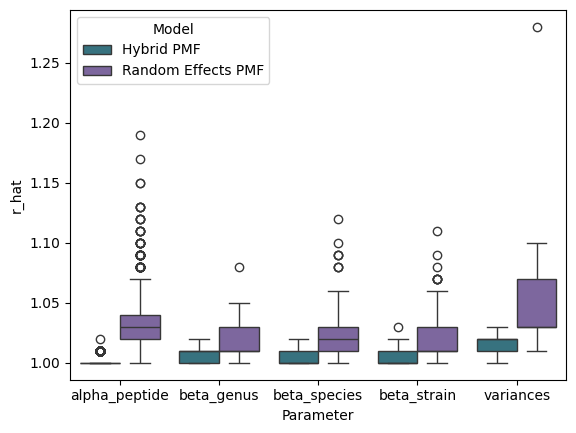

In [ ]:
## Plot boxplots comparing two models

plot_vars = ["alpha_peptide",
             "beta_genus", "beta_species", "beta_strain",
              "U",
             "V_genus", "V_species", "V_strains",
             "variances"]
colors = {'Hybrid PMF': '#2b7a8bff',
          'Random Effects PMF': '#7b5ea7ff'}
hue_order = ['Hybrid PMF', 'Random Effects PMF']

sns.boxplot(combined_df[combined_df['Parameter'].isin(plot_vars)], x='Parameter', y='r_hat',
            hue='Model', palette=colors, hue_order=hue_order)

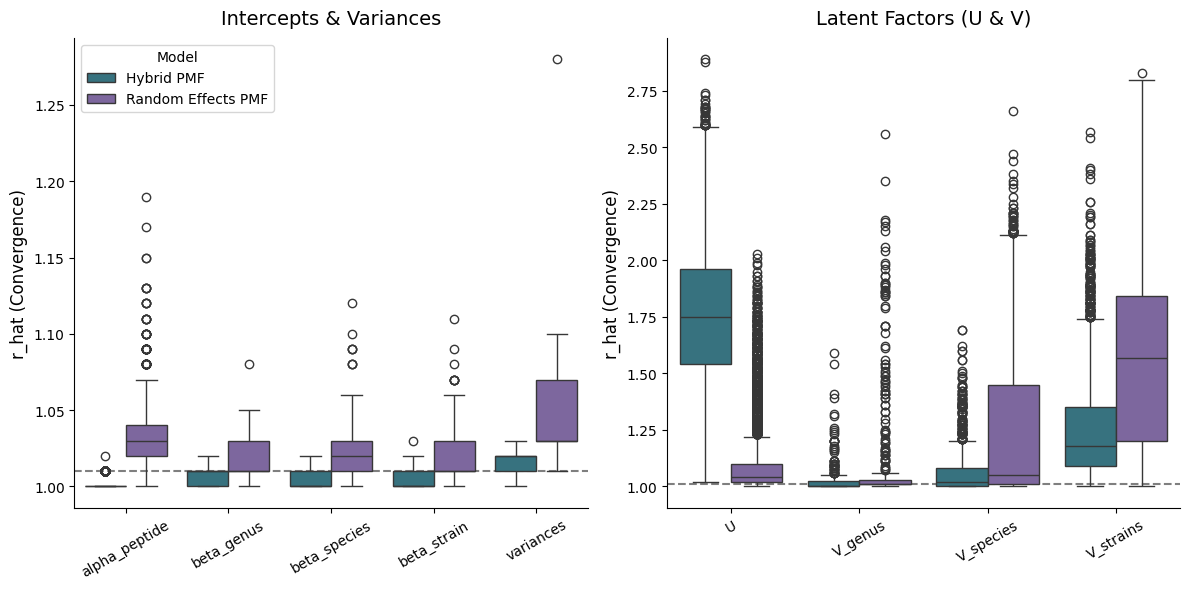

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define variables
plot_vars = ["alpha_peptide", "beta_genus", "beta_species", "beta_strain", "variances"]
plot_vars_2 = ["U", "V_genus", "V_species", "V_strains"]
colors = {'Hybrid PMF': '#2b7a8bff', 'Random Effects PMF': '#7b5ea7ff'}
hue_order = ['Hybrid PMF', 'Random Effects PMF']

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Left Plot (Standard Parameters) ---
sns.boxplot(
    data=combined_df[combined_df['Parameter'].isin(plot_vars)],
    x='Parameter',
    y='r_hat',
    hue='Model',
    palette=colors,
    hue_order=hue_order,
    ax=axes[0]
)

# --- Right Plot (Latent Factors) ---
sns.boxplot(
    data=combined_df[combined_df['Parameter'].isin(plot_vars_2)],
    x='Parameter',
    y='r_hat',
    hue='Model',
    palette=colors,
    hue_order=hue_order,
    ax=axes[1]
)

# --- Formatting & Aesthetics ---
axes[0].set_title("Intercepts & Variances", fontsize=14, pad=10)
axes[1].set_title("Latent Factors (U & V)", fontsize=14, pad=10)

for ax in axes:
    # Clean up axes labels
    ax.set_ylabel("r_hat (Convergence)", fontsize=12)
    ax.set_xlabel("") # Remove the redundant 'Parameter' label

    # Rotate x-tick labels to prevent overlapping
    ax.tick_params(axis='x', rotation=30)

    # Add a reference line for ideal convergence (r_hat = 1.0)
    ax.axhline(1.01, color='black', linestyle='--', alpha=0.5, zorder=0)

# Clean up the duplicate legends
axes[1].get_legend().remove()
axes[0].legend(title="Model", frameon=True, loc='upper left')

# Remove top and right borders for a cleaner look
sns.despine(fig)

plt.tight_layout()
plt.savefig(os.path.join(file_path, 'figures', 'convergence.hpmf_and_random_effects.png'), bbox_inches='tight')

plt.show()

## RMSE Values

In [ ]:
tmp = train_random_effects_out.groupby('Peptide ID').size()
single_peptides = tmp[tmp == 1].index
five_peptides = tmp[tmp == 5].index
gt20_peptides = tmp[tmp > 20].index
gt50_peptides = tmp[tmp > 50].index

np.sqrt(np.mean(train_random_effects_out[train_random_effects_out['Peptide ID'].isin(single_peptides)]['error'] ** 2))

np.sqrt(np.mean(train_ESMmixed_Hie_out[train_ESMmixed_Hie_out['Peptide ID'].isin(single_peptides)]['error'] ** 2))

In [ ]:
np.sqrt(np.mean(train_random_effects_out[train_random_effects_out['Peptide ID'].isin(single_peptides)]['error'] ** 2))

np.float64(0.5863053394135749)

In [ ]:
np.sqrt(np.mean(train_random_effects_out[train_random_effects_out['Peptide ID'].isin(five_peptides)]['error'] ** 2))

np.float64(0.6406016829833177)

In [ ]:
np.sqrt(np.mean(train_random_effects_out[train_random_effects_out['Peptide ID'].isin(gt20_peptides)]['error'] ** 2))

np.float64(1.0668965993655777)

In [ ]:
np.sqrt(np.mean(train_random_effects_out[train_random_effects_out['Peptide ID'].isin(gt50_peptides)]['error'] ** 2))

np.float64(1.0843529227738482)

In [ ]:
np.sqrt(np.mean(train_ESMmixed_Hie_out[train_ESMmixed_Hie_out['Peptide ID'].isin(single_peptides)]['error'] ** 2))

np.float64(1.9470119175601177)

In [ ]:
np.sqrt(np.mean(train_ESMmixed_Hie_out[train_ESMmixed_Hie_out['Peptide ID'].isin(five_peptides)]['error'] ** 2))

np.float64(1.7705612129735044)

In [ ]:
np.sqrt(np.mean(train_ESMmixed_Hie_out[train_ESMmixed_Hie_out['Peptide ID'].isin(gt50_peptides)]['error'] ** 2))

np.float64(1.6069746452428049)

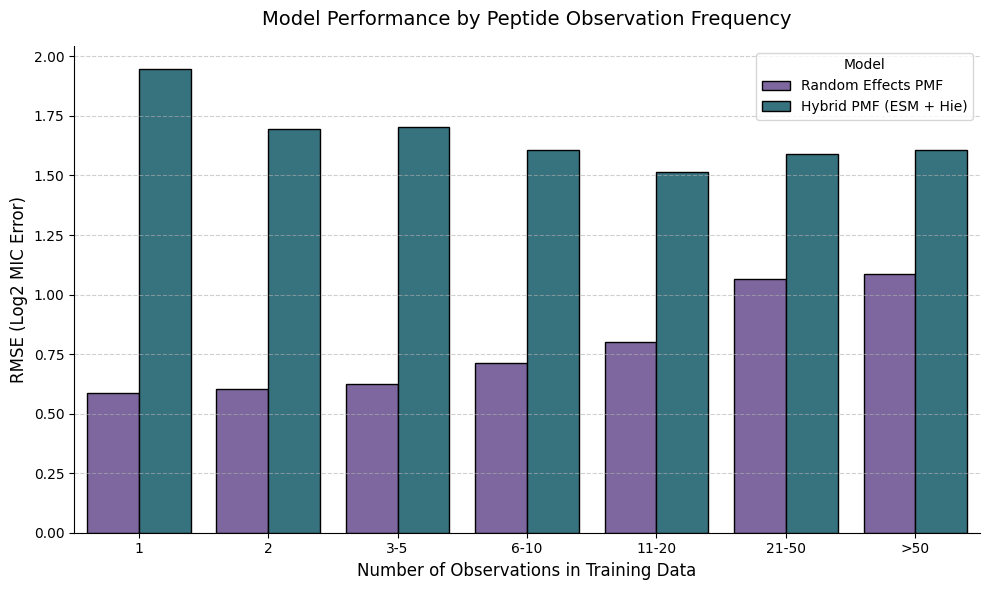

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate frequency map for all peptides
# (Assuming both dataframes have the exact same training peptides)
peptide_counts = train_random_effects_out['Peptide ID'].value_counts()

# 2. Define bins for the counts
# This creates groups: 1, 2, 3-5, 6-10, 11-20, 21-50, >50
bins = [0, 1, 2, 5, 10, 20, 50, np.inf]
labels = ['1', '2', '3-5', '6-10', '11-20', '21-50', '>50']

# Map the raw counts into these categorical bins
peptide_bins = pd.cut(peptide_counts, bins=bins, labels=labels)

# 3. Apply the bins to your output dataframes
df_rand = train_random_effects_out.copy()
df_hie = train_ESMmixed_Hie_out.copy()

df_rand['Count_Bin'] = df_rand['Peptide ID'].map(peptide_bins)
df_hie['Count_Bin'] = df_hie['Peptide ID'].map(peptide_bins)

# 4. Define a quick RMSE function
def calculate_rmse(x):
    return np.sqrt(np.mean(x**2))

# 5. Calculate RMSE per bin for both models
rmse_rand = df_rand.groupby('Count_Bin', observed=False)['error'].apply(calculate_rmse).reset_index()
rmse_rand['Model'] = 'Random Effects PMF'

rmse_hie = df_hie.groupby('Count_Bin', observed=False)['error'].apply(calculate_rmse).reset_index()
rmse_hie['Model'] = 'Hybrid PMF (ESM + Hie)'

# Combine into a single dataframe for Seaborn
plot_df = pd.concat([rmse_rand, rmse_hie])

# 6. Plotting
plt.figure(figsize=(10, 6))

# Use the same color palette from your previous plots
colors = {'Hybrid PMF (ESM + Hie)': '#2b7a8bff', 'Random Effects PMF': '#7b5ea7ff'}

sns.barplot(
    data=plot_df,
    x='Count_Bin',
    y='error',
    hue='Model',
    palette=colors,
    edgecolor='black',
    linewidth=1
)

# Formatting
plt.title("Model Performance by Peptide Observation Frequency", fontsize=14, pad=15)
plt.xlabel("Number of Observations in Training Data", fontsize=12)
plt.ylabel("RMSE (Log2 MIC Error)", fontsize=12)

# Legend formatting
plt.legend(title="Model", frameon=True, loc='upper right')

# Add subtle horizontal grid lines for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()

plt.tight_layout()
plt.show()

In [ ]:
rmse_rand

,Count_Bin,error,Model
0,1,2.453684,Random Effects PMF
1,2,2.136064,Random Effects PMF
2,3-5,2.395637,Random Effects PMF
3,6-10,2.215065,Random Effects PMF
4,11-20,2.551481,Random Effects PMF
5,21-50,2.661975,Random Effects PMF
6,>50,NaN,Random Effects PMF


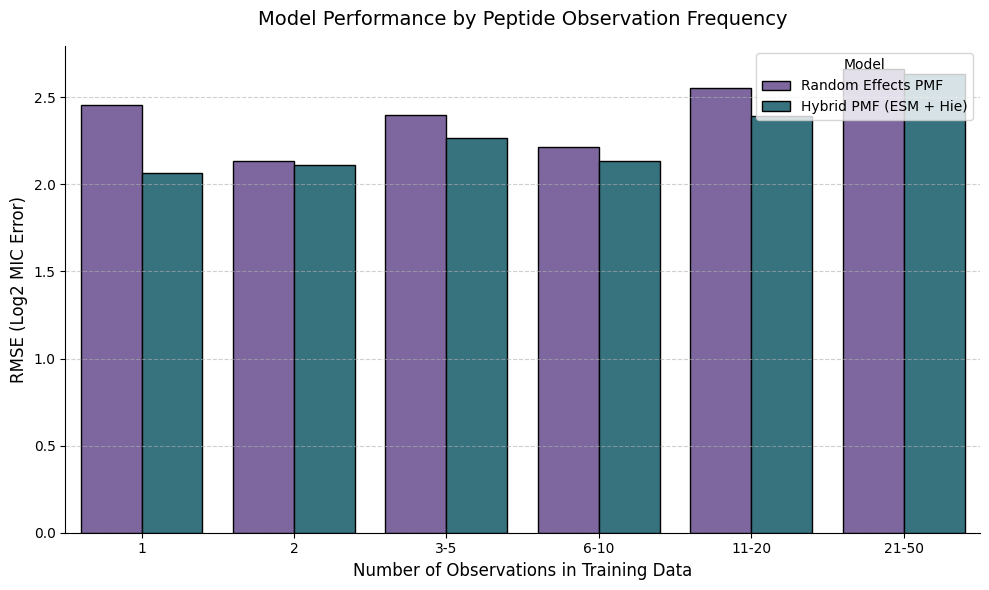

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate frequency map for all peptides
# (Assuming both dataframes have the exact same training peptides)
peptide_counts = test_random_effects_out['Peptide ID'].value_counts()

# 2. Define bins for the counts
# This creates groups: 1, 2, 3-5, 6-10, 11-20, 21-50, >50
bins = [0, 1, 2, 5, 10, 20, 50]
labels = ['1', '2', '3-5', '6-10', '11-20', '21-50']

# Map the raw counts into these categorical bins
peptide_bins = pd.cut(peptide_counts, bins=bins, labels=labels)

# 3. Apply the bins to your output dataframes
df_rand = test_random_effects_out.copy()
df_hie = test_ESMmixed_Hie_out.copy()

df_rand['Count_Bin'] = df_rand['Peptide ID'].map(peptide_bins)
df_hie['Count_Bin'] = df_hie['Peptide ID'].map(peptide_bins)

# 4. Define a quick RMSE function
def calculate_rmse(x):
    return np.sqrt(np.mean(x**2))

# 5. Calculate RMSE per bin for both models
rmse_rand = df_rand.groupby('Count_Bin', observed=False)['error'].apply(calculate_rmse).reset_index()
rmse_rand['Model'] = 'Random Effects PMF'

rmse_hie = df_hie.groupby('Count_Bin', observed=False)['error'].apply(calculate_rmse).reset_index()
rmse_hie['Model'] = 'Hybrid PMF (ESM + Hie)'

# Combine into a single dataframe for Seaborn
plot_df = pd.concat([rmse_rand, rmse_hie])

# 6. Plotting
plt.figure(figsize=(10, 6))

# Use the same color palette from your previous plots
colors = {'Hybrid PMF (ESM + Hie)': '#2b7a8bff', 'Random Effects PMF': '#7b5ea7ff'}

sns.barplot(
    data=plot_df,
    x='Count_Bin',
    y='error',
    hue='Model',
    palette=colors,
    edgecolor='black',
    linewidth=1
)

# Formatting
plt.title("Model Performance by Peptide Observation Frequency", fontsize=14, pad=15)
plt.xlabel("Number of Observations in Testing Data", fontsize=12)
plt.ylabel("RMSE (Log2 MIC Error)", fontsize=12)

# Legend formatting
plt.legend(title="Model", frameon=True, loc='upper right')

# Add subtle horizontal grid lines for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()

plt.tight_layout()
plt.show()